# CELL 1 — Import dan setup path

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx

import pm4py
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator
from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Deteksi root project
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data processed:", DATA_PROCESSED_DIR)
print("Output tables:", OUTPUT_TABLES_DIR)
print("Output figures:", OUTPUT_FIGURES_DIR)
print("PM4Py version:", pm4py.__version__)

Project root: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL
Data processed: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\data\processed
Output tables: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\tables
Output figures: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures
PM4Py version: 2.7.22.4


# CELL 2 — Load compact log

In [2]:
COMPACT_LOG_PATH = DATA_PROCESSED_DIR / "04_compact_log_process_ready.csv"

compact_log = pd.read_csv(COMPACT_LOG_PATH)

print("Shape compact log:", compact_log.shape)
print("Kolom:")
print(compact_log.columns.tolist())

display(compact_log.head())

Shape compact log: (116611, 18)
Kolom:
['case_id', 'activity', 'timestamp', 'kelas', 'Component', 'Event context', 'Description', 'Origin', 'IP address', 'nim', 'nama', 'nilai_total', 'nilai_indeks', 'label_performance', 'activity_mapped', 'activity_category', 'event_order', 'compact_event_order']


,case_id,activity,timestamp,kelas,Component,Event context,Description,Origin,IP address,nim,nama,nilai_total,nilai_indeks,label_performance,activity_mapped,activity_category,event_order,compact_event_order
0,ADITYA PUTRA PERMANA,Course viewed,2025-09-18 13:30:09,IF-49-02,System,Course: KALKULUS IF-49-02 [DLW],The user with id &#039;124462&#039; viewed the...,web,103.233.100.204,103012530065,ADITYA PUTRA PERMANA,73.01,B,Sedang,Course Viewed,course,1,1
1,ADITYA PUTRA PERMANA,Course module viewed,2025-09-18 14:24:42,IF-49-02,File,File: Materi 1 Sistem Bilangan Riil dan Pertak...,The user with id &#039;124462&#039; viewed the...,web,103.233.100.202,103012530065,ADITYA PUTRA PERMANA,73.01,B,Sedang,Material Viewed,material,4,2
2,ADITYA PUTRA PERMANA,Course viewed,2025-09-18 15:41:24,IF-49-02,System,Course: KALKULUS IF-49-02 [DLW],The user with id &#039;124462&#039; viewed the...,web,103.233.100.202,103012530065,ADITYA PUTRA PERMANA,73.01,B,Sedang,Course Viewed,course,5,3
3,ADITYA PUTRA PERMANA,Course module viewed,2025-09-18 15:41:57,IF-49-02,File,File: Materi 1 Sistem Bilangan Riil dan Pertak...,The user with id &#039;124462&#039; viewed the...,web,103.233.100.202,103012530065,ADITYA PUTRA PERMANA,73.01,B,Sedang,Material Viewed,material,6,4
4,ADITYA PUTRA PERMANA,Course viewed,2025-09-18 16:40:55,IF-49-02,System,Course: KALKULUS IF-49-02 [DLW],The user with id &#039;124462&#039; viewed the...,web,36.72.198.4,103012530065,ADITYA PUTRA PERMANA,73.01,B,Sedang,Course Viewed,course,7,5


In [3]:
required_columns = [
    "case_id",
    "activity_mapped",
    "timestamp",
    "label_performance"
]

missing_columns = [col for col in required_columns if col not in compact_log.columns]

if missing_columns:
    raise ValueError(f"Kolom berikut tidak ditemukan: {missing_columns}")
else:
    print("Semua kolom utama tersedia.")

Semua kolom utama tersedia.


# CELL 3 — Filter menjadi main learning log

In [4]:
MAIN_LEARNING_ACTIVITIES = [
    "Course Viewed",
    "Material Viewed",
    "Quiz Module Viewed",
    "Quiz Access Prevented",
    "Quiz Started",
    "Quiz Viewed",
    "Quiz Updated",
    "Quiz Auto-saved",
    "Quiz Summary Viewed",
    "Quiz Submitted"
]

main_learning_log = compact_log[
    compact_log["activity_mapped"].isin(MAIN_LEARNING_ACTIVITIES)
].copy()

main_learning_log["timestamp"] = pd.to_datetime(main_learning_log["timestamp"])

main_learning_log = main_learning_log.sort_values(
    by=["case_id", "timestamp"]
).reset_index(drop=True)

print("Shape main learning log:", main_learning_log.shape)
print("Jumlah mahasiswa:", main_learning_log["case_id"].nunique())
print("Jumlah event:", len(main_learning_log))
print("Jumlah aktivitas:", main_learning_log["activity_mapped"].nunique())

display(main_learning_log.head())

Shape main learning log: (113803, 18)
Jumlah mahasiswa: 89
Jumlah event: 113803
Jumlah aktivitas: 10


,case_id,activity,timestamp,kelas,Component,Event context,Description,Origin,IP address,nim,nama,nilai_total,nilai_indeks,label_performance,activity_mapped,activity_category,event_order,compact_event_order
0,ADITYA PUTRA PERMANA,Course viewed,2025-09-18 13:30:09,IF-49-02,System,Course: KALKULUS IF-49-02 [DLW],The user with id &#039;124462&#039; viewed the...,web,103.233.100.204,103012530065,ADITYA PUTRA PERMANA,73.01,B,Sedang,Course Viewed,course,1,1
1,ADITYA PUTRA PERMANA,Course module viewed,2025-09-18 14:24:42,IF-49-02,File,File: Materi 1 Sistem Bilangan Riil dan Pertak...,The user with id &#039;124462&#039; viewed the...,web,103.233.100.202,103012530065,ADITYA PUTRA PERMANA,73.01,B,Sedang,Material Viewed,material,4,2
2,ADITYA PUTRA PERMANA,Course viewed,2025-09-18 15:41:24,IF-49-02,System,Course: KALKULUS IF-49-02 [DLW],The user with id &#039;124462&#039; viewed the...,web,103.233.100.202,103012530065,ADITYA PUTRA PERMANA,73.01,B,Sedang,Course Viewed,course,5,3
3,ADITYA PUTRA PERMANA,Course module viewed,2025-09-18 15:41:57,IF-49-02,File,File: Materi 1 Sistem Bilangan Riil dan Pertak...,The user with id &#039;124462&#039; viewed the...,web,103.233.100.202,103012530065,ADITYA PUTRA PERMANA,73.01,B,Sedang,Material Viewed,material,6,4
4,ADITYA PUTRA PERMANA,Course viewed,2025-09-18 16:40:55,IF-49-02,System,Course: KALKULUS IF-49-02 [DLW],The user with id &#039;124462&#039; viewed the...,web,36.72.198.4,103012530065,ADITYA PUTRA PERMANA,73.01,B,Sedang,Course Viewed,course,7,5


# CELL 4 — Cek distribusi log per performa

In [6]:
summary_by_performance = (
    main_learning_log
    .groupby("label_performance")
    .agg(
        jumlah_mahasiswa=("case_id", "nunique"),
        jumlah_event=("activity_mapped", "count"),
        jumlah_aktivitas=("activity_mapped", "nunique")
    )
    .reset_index()
)

# Urutkan label agar rapi
label_order = ["Rendah", "Sedang", "Tinggi"]

summary_by_performance["label_performance"] = pd.Categorical(
    summary_by_performance["label_performance"],
    categories=label_order,
    ordered=True
)

summary_by_performance = summary_by_performance.sort_values(
    "label_performance"
).reset_index(drop=True)

display(summary_by_performance)

SUMMARY_PATH = OUTPUT_TABLES_DIR / "14_main_learning_log_by_performance_summary.csv"

summary_by_performance.to_csv(
    SUMMARY_PATH,
    index=False
)

print("Tabel ringkasan log per performa disimpan ke:")
print(SUMMARY_PATH)

,label_performance,jumlah_mahasiswa,jumlah_event,jumlah_aktivitas
0,Rendah,15,11530,10
1,Sedang,54,72873,10
2,Tinggi,20,29400,10


Tabel ringkasan log per performa disimpan ke:
e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\tables\14_main_learning_log_by_performance_summary.csv


# CELL 5 — Fungsi menghitung transisi

In [7]:
def calculate_transitions(df, case_col="case_id", activity_col="activity_mapped", timestamp_col="timestamp"):
    df_sorted = df.sort_values(by=[case_col, timestamp_col]).copy()
    
    df_sorted["source"] = df_sorted[activity_col]
    df_sorted["target"] = df_sorted.groupby(case_col)[activity_col].shift(-1)
    
    transitions = df_sorted.dropna(subset=["target"]).copy()
    
    transition_counts = (
        transitions
        .groupby(["source", "target"])
        .size()
        .reset_index(name="frequency")
        .sort_values("frequency", ascending=False)
        .reset_index(drop=True)
    )
    
    total_transition = transition_counts["frequency"].sum()
    transition_counts["percentage"] = transition_counts["frequency"] / total_transition * 100
    
    return transition_counts

# CELL 6 — Hitung Transisi

In [14]:
all_transitions = []
all_top10_transitions = []

for label in label_order:
    group_df = main_learning_log[
        main_learning_log["label_performance"] == label
    ].copy()
    
    transitions_df = calculate_transitions(group_df)
    transitions_df.insert(0, "label_performance", label)
    transitions_df.insert(1, "rank", range(1, len(transitions_df) + 1))
    
    all_transitions.append(transitions_df)
    all_top10_transitions.append(transitions_df.head(10).copy())
    
    print(f"\nSemua transisi kelompok {label}:")
    display(transitions_df)
    
    print(f"\nTop 10 transisi kelompok {label}:")
    display(transitions_df.head(10))

transitions_by_performance = pd.concat(
    all_transitions,
    ignore_index=True
)

top10_transitions_by_performance = pd.concat(
    all_top10_transitions,
    ignore_index=True
)

ALL_TRANSITION_PATH = OUTPUT_TABLES_DIR / "14_all_transitions_by_performance.csv"
TOP10_TRANSITION_PATH = OUTPUT_TABLES_DIR / "14_top10_transitions_by_performance.csv"

transitions_by_performance.to_csv(ALL_TRANSITION_PATH, index=False)
top10_transitions_by_performance.to_csv(TOP10_TRANSITION_PATH, index=False)

print("Semua transisi per performa disimpan ke:")
print(ALL_TRANSITION_PATH)

print("Top 10 transisi per performa disimpan ke:")
print(TOP10_TRANSITION_PATH)


Semua transisi kelompok Rendah:


,label_performance,rank,source,target,frequency,percentage
0,Rendah,1,Quiz Viewed,Quiz Updated,3840,33.347807
1,Rendah,2,Quiz Updated,Quiz Viewed,3526,30.620929
2,Rendah,3,Quiz Module Viewed,Course Viewed,358,3.108988
3,Rendah,4,Course Viewed,Material Viewed,273,2.370821
4,Rendah,5,Quiz Updated,Quiz Summary Viewed,266,2.310030
5,Rendah,6,Quiz Module Viewed,Quiz Viewed,263,2.283977
6,Rendah,7,Course Viewed,Quiz Module Viewed,248,2.153713
7,Rendah,8,Quiz Submitted,Quiz Module Viewed,237,2.058185
8,Rendah,9,Quiz Access Prevented,Quiz Module Viewed,225,1.953973
9,Rendah,10,Material Viewed,Course Viewed,221,1.919236



Top 10 transisi kelompok Rendah:


,label_performance,rank,source,target,frequency,percentage
0,Rendah,1,Quiz Viewed,Quiz Updated,3840,33.347807
1,Rendah,2,Quiz Updated,Quiz Viewed,3526,30.620929
2,Rendah,3,Quiz Module Viewed,Course Viewed,358,3.108988
3,Rendah,4,Course Viewed,Material Viewed,273,2.370821
4,Rendah,5,Quiz Updated,Quiz Summary Viewed,266,2.310030
5,Rendah,6,Quiz Module Viewed,Quiz Viewed,263,2.283977
6,Rendah,7,Course Viewed,Quiz Module Viewed,248,2.153713
7,Rendah,8,Quiz Submitted,Quiz Module Viewed,237,2.058185
8,Rendah,9,Quiz Access Prevented,Quiz Module Viewed,225,1.953973
9,Rendah,10,Material Viewed,Course Viewed,221,1.919236



Semua transisi kelompok Sedang:


...


Semua transisi kelompok Tinggi:


,label_performance,rank,source,target,frequency,percentage
0,Tinggi,1,Quiz Viewed,Quiz Updated,9632,32.784207
1,Tinggi,2,Quiz Updated,Quiz Viewed,8729,29.710688
2,Tinggi,3,Course Viewed,Material Viewed,1014,3.451327
3,Tinggi,4,Quiz Auto-saved,Quiz Viewed,1002,3.410483
4,Tinggi,5,Quiz Updated,Quiz Auto-saved,969,3.298162
5,Tinggi,6,Material Viewed,Course Viewed,879,2.991831
6,Tinggi,7,Quiz Module Viewed,Course Viewed,772,2.627638
7,Tinggi,8,Course Viewed,Quiz Module Viewed,568,1.933288
8,Tinggi,9,Quiz Auto-saved,Quiz Updated,551,1.875425
9,Tinggi,10,Quiz Viewed,Quiz Auto-saved,519,1.766508



Top 10 transisi kelompok Tinggi:


,label_performance,rank,source,target,frequency,percentage
0,Tinggi,1,Quiz Viewed,Quiz Updated,9632,32.784207
1,Tinggi,2,Quiz Updated,Quiz Viewed,8729,29.710688
2,Tinggi,3,Course Viewed,Material Viewed,1014,3.451327
3,Tinggi,4,Quiz Auto-saved,Quiz Viewed,1002,3.410483
4,Tinggi,5,Quiz Updated,Quiz Auto-saved,969,3.298162
5,Tinggi,6,Material Viewed,Course Viewed,879,2.991831
6,Tinggi,7,Quiz Module Viewed,Course Viewed,772,2.627638
7,Tinggi,8,Course Viewed,Quiz Module Viewed,568,1.933288
8,Tinggi,9,Quiz Auto-saved,Quiz Updated,551,1.875425
9,Tinggi,10,Quiz Viewed,Quiz Auto-saved,519,1.766508


Semua transisi per performa disimpan ke:
e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\tables\14_all_transitions_by_performance.csv
Top 10 transisi per performa disimpan ke:
e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\tables\14_top10_transitions_by_performance.csv


# CELL 6B — Buat edge referensi dari DFG global

In [17]:
# Membuat DFG global dari seluruh main learning log
global_transitions = calculate_transitions(main_learning_log)

print("Top 10 transisi global main learning log:")
display(global_transitions.head(10))

# Ambil top 10 transisi global sebagai edge referensi
reference_edges = (
    global_transitions
    .head(10)[["source", "target"]]
    .copy()
)

reference_edges["edge_order"] = range(1, len(reference_edges) + 1)

display(reference_edges)

REFERENCE_EDGE_PATH = OUTPUT_TABLES_DIR / "14_reference_edges_global_top10.csv"
reference_edges.to_csv(REFERENCE_EDGE_PATH, index=False)

print("Edge referensi global disimpan ke:")
print(REFERENCE_EDGE_PATH)

Top 10 transisi global main learning log:


,source,target,frequency,percentage
0,Quiz Viewed,Quiz Updated,38710,34.041543
1,Quiz Updated,Quiz Viewed,35519,31.235380
2,Quiz Module Viewed,Course Viewed,3106,2.731414
3,Course Viewed,Material Viewed,2914,2.562569
4,Quiz Updated,Quiz Auto-saved,2864,2.518599
5,Quiz Auto-saved,Quiz Viewed,2853,2.508926
6,Material Viewed,Course Viewed,2512,2.209051
7,Course Viewed,Quiz Module Viewed,2301,2.023498
8,Quiz Updated,Quiz Summary Viewed,2180,1.917090
9,Quiz Module Viewed,Quiz Viewed,1993,1.752643


,source,target,edge_order
0,Quiz Viewed,Quiz Updated,1
1,Quiz Updated,Quiz Viewed,2
2,Quiz Module Viewed,Course Viewed,3
3,Course Viewed,Material Viewed,4
4,Quiz Updated,Quiz Auto-saved,5
5,Quiz Auto-saved,Quiz Viewed,6
6,Material Viewed,Course Viewed,7
7,Course Viewed,Quiz Module Viewed,8
8,Quiz Updated,Quiz Summary Viewed,9
9,Quiz Module Viewed,Quiz Viewed,10


Edge referensi global disimpan ke:
e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\tables\14_reference_edges_global_top10.csv


# CELL 6C — Hitung frekuensi edge global pada tiap performa

In [18]:
fixed_edge_rows = []

# Tambahkan global dulu sebagai pembanding
global_transition_lookup = global_transitions.copy()

global_fixed = reference_edges.merge(
    global_transition_lookup,
    on=["source", "target"],
    how="left"
)

global_fixed["label_performance"] = "Global"
global_fixed["frequency"] = global_fixed["frequency"].fillna(0).astype(int)

fixed_edge_rows.append(global_fixed)

# Hitung frekuensi edge yang sama pada tiap kelompok performa
for label in label_order:
    group_df = main_learning_log[
        main_learning_log["label_performance"] == label
    ].copy()
    
    group_transitions = calculate_transitions(group_df)
    
    group_fixed = reference_edges.merge(
        group_transitions,
        on=["source", "target"],
        how="left"
    )
    
    group_fixed["label_performance"] = label
    group_fixed["frequency"] = group_fixed["frequency"].fillna(0).astype(int)
    
    fixed_edge_rows.append(group_fixed)

fixed_edges_by_performance = pd.concat(
    fixed_edge_rows,
    ignore_index=True
)

fixed_edges_by_performance = fixed_edges_by_performance[
    [
        "label_performance",
        "edge_order",
        "source",
        "target",
        "frequency"
    ]
]

display(fixed_edges_by_performance)

FIXED_EDGE_PATH = OUTPUT_TABLES_DIR / "14_fixed_global_edges_by_performance.csv"
fixed_edges_by_performance.to_csv(FIXED_EDGE_PATH, index=False)

print("Tabel edge global tetap per performa disimpan ke:")
print(FIXED_EDGE_PATH)

,label_performance,edge_order,source,target,frequency
0,Global,1,Quiz Viewed,Quiz Updated,38710
1,Global,2,Quiz Updated,Quiz Viewed,35519
2,Global,3,Quiz Module Viewed,Course Viewed,3106
3,Global,4,Course Viewed,Material Viewed,2914
4,Global,5,Quiz Updated,Quiz Auto-saved,2864
5,Global,6,Quiz Auto-saved,Quiz Viewed,2853
6,Global,7,Material Viewed,Course Viewed,2512
7,Global,8,Course Viewed,Quiz Module Viewed,2301
8,Global,9,Quiz Updated,Quiz Summary Viewed,2180
9,Global,10,Quiz Module Viewed,Quiz Viewed,1993


Tabel edge global tetap per performa disimpan ke:
e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\tables\14_fixed_global_edges_by_performance.csv


# CELL 7 — Fungsi visualisasi DFG

In [19]:
def plot_fixed_global_edge_dfg(edge_df, title, output_path=None):
    """
    Visualisasi DFG menggunakan edge referensi global.
    Struktur edge sama untuk Global, Rendah, Sedang, dan Tinggi.
    Yang berbeda hanya frekuensinya.
    """

    plot_df = edge_df.copy()
    plot_df = plot_df[plot_df["frequency"] > 0].copy()

    G = nx.DiGraph()

    for _, row in plot_df.iterrows():
        G.add_edge(
            row["source"],
            row["target"],
            weight=int(row["frequency"])
        )

    # Layout dibuat mirip gambar global main learning log sebelumnya
    pos = {
        "Material Viewed": (-3.5, 1.5),
        "Course Viewed": (0, 0),
        "Quiz Module Viewed": (3.2, 0),
        "Quiz Access Prevented": (2.4, -2.5),
        "Quiz Started": (6.3, -2.5),
        "Quiz Viewed": (6.3, 0),
        "Quiz Updated": (9.2, 0),
        "Quiz Auto-saved": (9.2, -2.5),
        "Quiz Summary Viewed": (12.2, 1.5),
        "Quiz Submitted": (12.2, -0.8),
    }

    for i, node in enumerate(G.nodes()):
        if node not in pos:
            pos[node] = (0, -4 - i)

    plt.figure(figsize=(18, 10))

    if len(G.edges()) > 0:
        edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
        max_weight = max(edge_weights)
        min_weight = min(edge_weights)

        edge_widths = []
        for weight in edge_weights:
            if max_weight == min_weight:
                width = 3
            else:
                width = 1.2 + ((weight - min_weight) / (max_weight - min_weight)) * 7
            edge_widths.append(width)
    else:
        edge_widths = []

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=5000,
        alpha=0.9,
        edgecolors="black",
        linewidths=2
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=10,
        font_weight="bold"
    )

    for idx, (u, v) in enumerate(G.edges()):
        if G.has_edge(v, u):
            rad = 0.22 if str(u) < str(v) else -0.22
        else:
            rad = 0.10

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[(u, v)],
            arrows=True,
            arrowstyle="-|>",
            arrowsize=28,
            width=edge_widths[idx],
            alpha=0.75,
            edge_color="black",
            connectionstyle=f"arc3,rad={rad}",
            min_source_margin=24,
            min_target_margin=30
        )

    edge_labels = {
        (u, v): f"{G[u][v]['weight']:,}".replace(",", ".")
        for u, v in G.edges()
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=9,
        font_weight="bold",
        rotate=False,
        bbox=dict(
            boxstyle="round,pad=0.20",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )

    plt.title(title, fontsize=17, fontweight="bold", pad=18)
    plt.axis("off")
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=400, bbox_inches="tight")
        print("Gambar disimpan:", output_path)

    plt.show()

# CELL 8 — Buat DFG per kelompok performa

Gambar disimpan: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures\14_dfg_fixed_global_edges_global.png


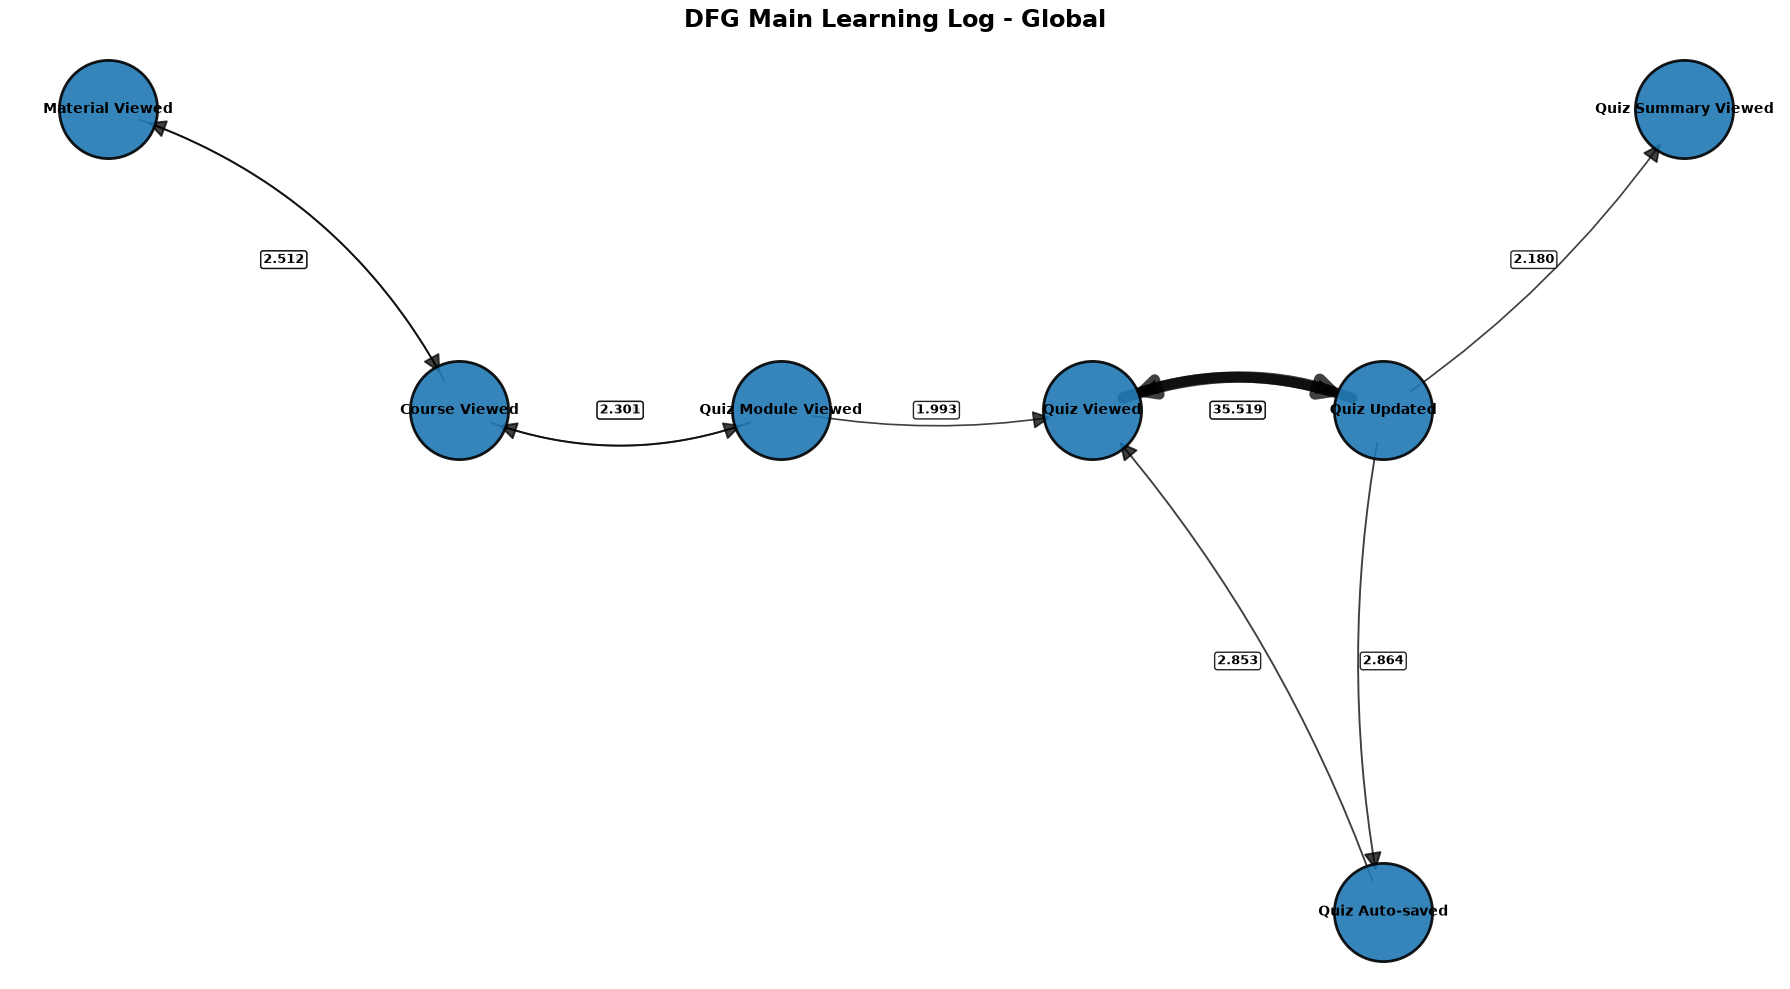

Gambar disimpan: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures\14_dfg_fixed_global_edges_rendah.png


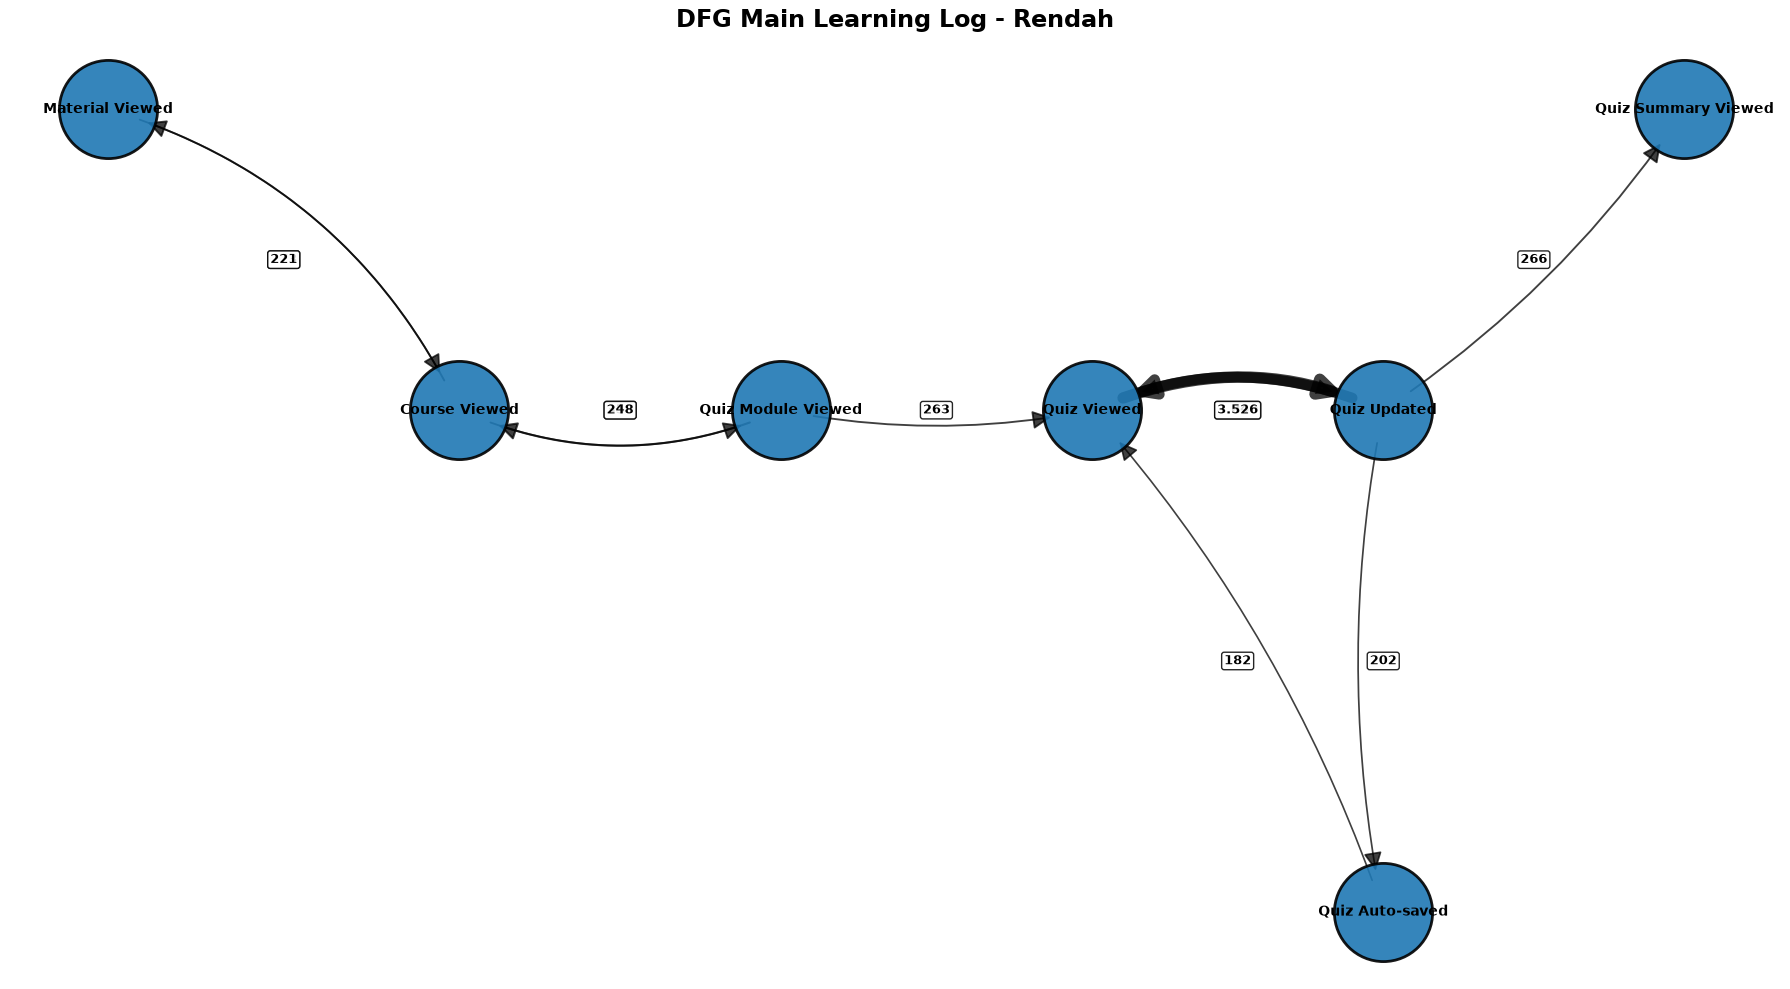

Gambar disimpan: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures\14_dfg_fixed_global_edges_sedang.png


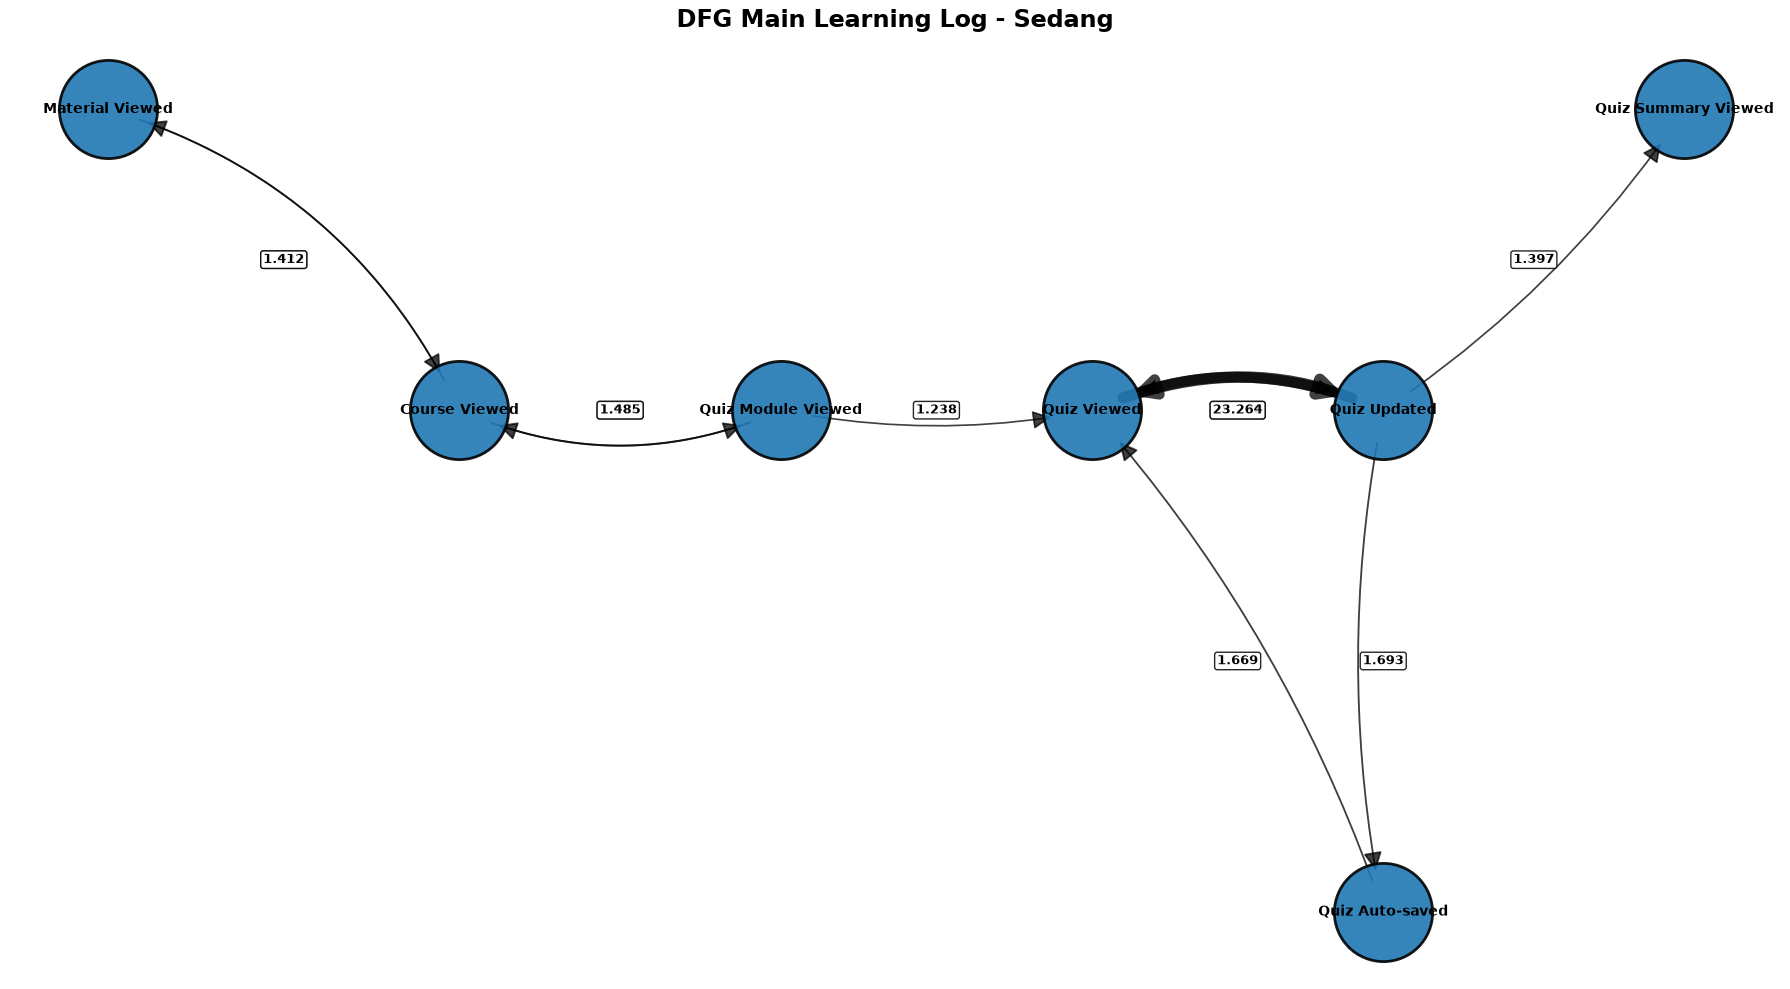

Gambar disimpan: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures\14_dfg_fixed_global_edges_tinggi.png


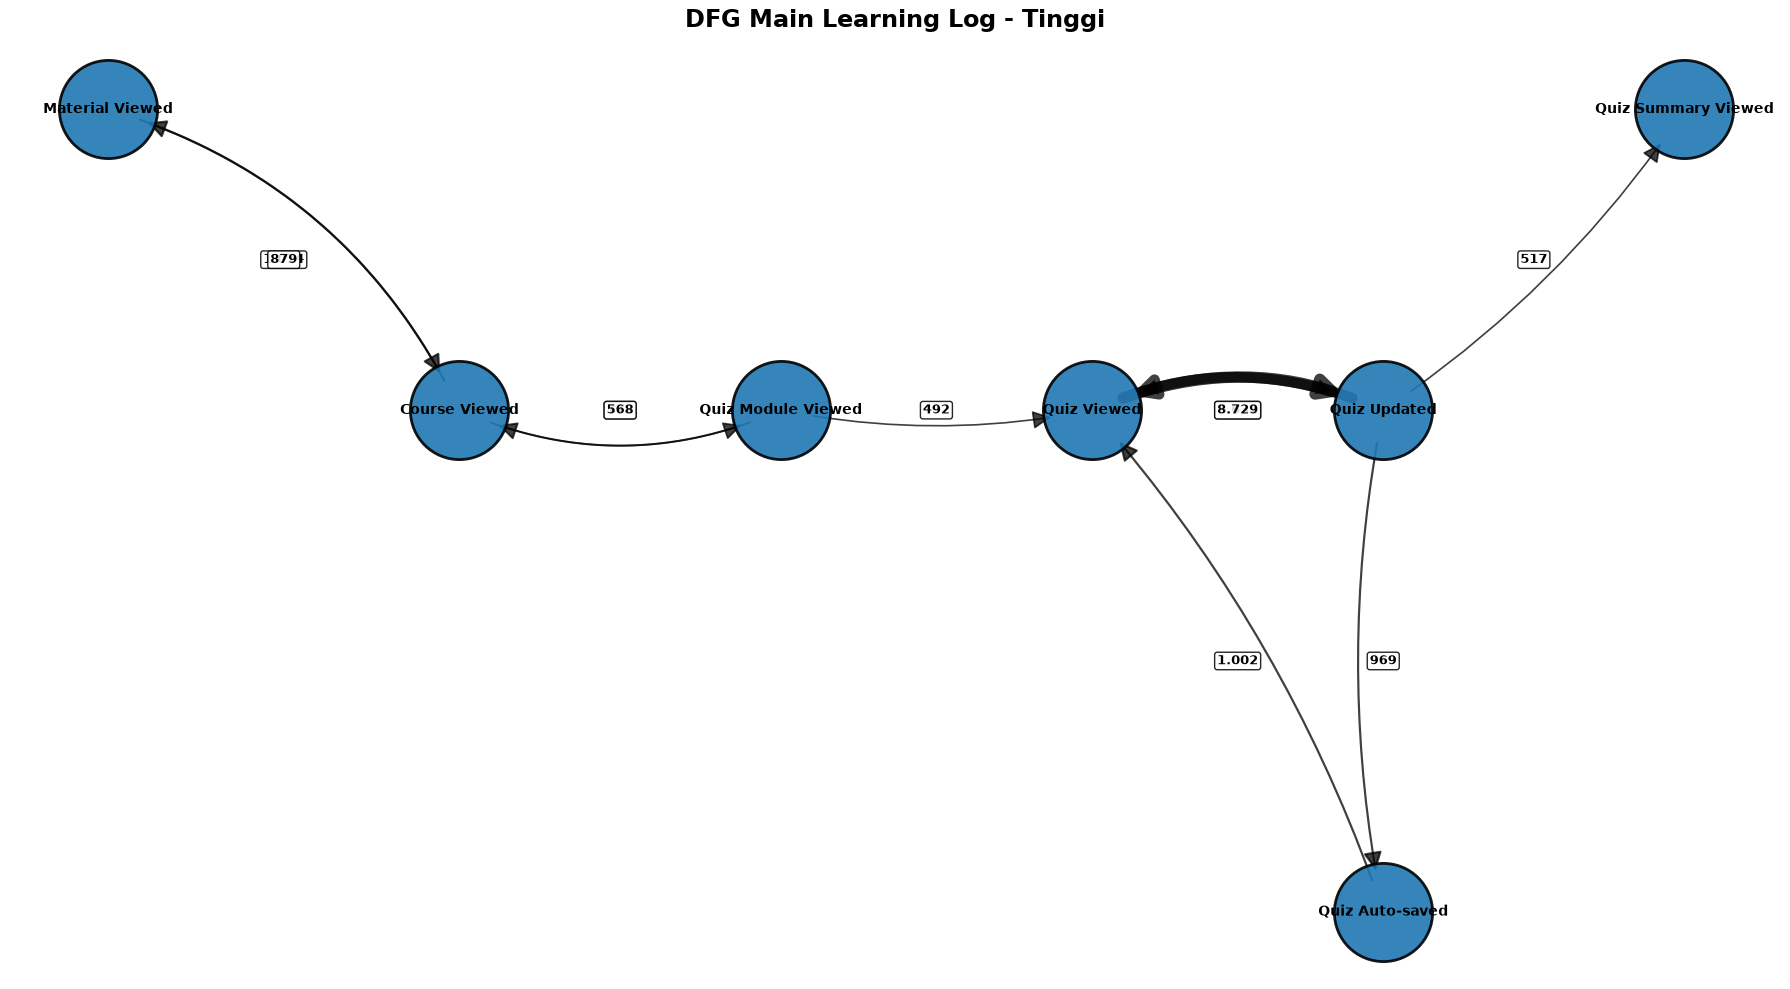

In [20]:
plot_order = ["Global", "Rendah", "Sedang", "Tinggi"]

for label in plot_order:
    plot_df = fixed_edges_by_performance[
        fixed_edges_by_performance["label_performance"] == label
    ].copy()

    safe_label = label.lower()

    output_path = OUTPUT_FIGURES_DIR / f"14_dfg_fixed_global_edges_{safe_label}.png"

    title = f"DFG Main Learning Log - {label}"

    plot_fixed_global_edge_dfg(
        edge_df=plot_df,
        title=title,
        output_path=output_path
    )

# CELL 9 — Format data untuk PM4Py

In [21]:
def prepare_pm4py_dataframe(df):
    pm_df = df[[
        "case_id",
        "activity_mapped",
        "timestamp"
    ]].copy()
    
    pm_df = pm_df.rename(columns={
        "case_id": "case:concept:name",
        "activity_mapped": "concept:name",
        "timestamp": "time:timestamp"
    })
    
    pm_df["time:timestamp"] = pd.to_datetime(pm_df["time:timestamp"])
    
    pm_df = pm_df.sort_values(
        by=["case:concept:name", "time:timestamp"]
    ).reset_index(drop=True)
    
    pm_df = pm4py.format_dataframe(
        pm_df,
        case_id="case:concept:name",
        activity_key="concept:name",
        timestamp_key="time:timestamp"
    )
    
    return pm_df

# CELL 10 — Fungsi ambil nilai fitness

In [22]:
def extract_fitness_value(fitness_result):
    if isinstance(fitness_result, dict):
        if "log_fitness" in fitness_result:
            return fitness_result["log_fitness"]
        if "average_trace_fitness" in fitness_result:
            return fitness_result["average_trace_fitness"]
    return fitness_result


def extract_fit_trace_percentage(fitness_result):
    if isinstance(fitness_result, dict):
        if "perc_fit_traces" in fitness_result:
            return fitness_result["perc_fit_traces"]
        if "percentage_of_fitting_traces" in fitness_result:
            return fitness_result["percentage_of_fitting_traces"]
    return None

# CELL 11 — Fungsi process discovery + conformance

In [23]:
def run_process_discovery_and_conformance(df, model_name, label_name):
    print("=" * 100)
    print(f"Memproses model: {model_name}")
    print("=" * 100)
    
    pm_df = prepare_pm4py_dataframe(df)
    event_log = pm4py.convert_to_event_log(pm_df)
    
    jumlah_case = pm_df["case:concept:name"].nunique()
    jumlah_event = len(pm_df)
    jumlah_activity = pm_df["concept:name"].nunique()
    
    print("Jumlah case:", jumlah_case)
    print("Jumlah event:", jumlah_event)
    print("Jumlah aktivitas:", jumlah_activity)
    
    print("Menjalankan Inductive Miner...")
    process_tree = pm4py.discover_process_tree_inductive(event_log)
    net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(event_log)
    
    print("Jumlah places:", len(net.places))
    print("Jumlah transitions:", len(net.transitions))
    
    safe_label = label_name.lower().replace(" ", "_")
    
    process_tree_path = OUTPUT_FIGURES_DIR / f"14_process_tree_{safe_label}.png"
    petri_net_path = OUTPUT_FIGURES_DIR / f"14_petri_net_{safe_label}.png"
    
    try:
        pm4py.save_vis_process_tree(process_tree, process_tree_path)
        print("Process tree disimpan:", process_tree_path)
    except Exception as e:
        print("Gagal menyimpan process tree:", e)
    
    try:
        pm4py.save_vis_petri_net(net, initial_marking, final_marking, petri_net_path)
        print("Petri net disimpan:", petri_net_path)
    except Exception as e:
        print("Gagal menyimpan Petri net:", e)
    
    print("Menghitung fitness...")
    fitness_result = pm4py.fitness_token_based_replay(
        event_log,
        net,
        initial_marking,
        final_marking
    )
    
    print("Menghitung precision...")
    precision_result = pm4py.precision_token_based_replay(
        event_log,
        net,
        initial_marking,
        final_marking
    )
    
    print("Menghitung generalization...")
    generalization_result = generalization_evaluator.apply(
        event_log,
        net,
        initial_marking,
        final_marking
    )
    
    print("Menghitung simplicity...")
    simplicity_result = simplicity_evaluator.apply(net)
    
    result = {
        "model": model_name,
        "label_performance": label_name,
        "jumlah_case": jumlah_case,
        "jumlah_event": jumlah_event,
        "jumlah_activity": jumlah_activity,
        "jumlah_places": len(net.places),
        "jumlah_transitions": len(net.transitions),
        "fitness": extract_fitness_value(fitness_result),
        "fit_trace_percentage": extract_fit_trace_percentage(fitness_result),
        "precision": precision_result,
        "generalization": generalization_result,
        "simplicity": simplicity_result,
        "process_tree_path": str(process_tree_path),
        "petri_net_path": str(petri_net_path)
    }
    
    display(pd.DataFrame([result]))
    
    return result

# CELL 12 — Jalankan untuk Global, Rendah, Sedang, Tinggi

In [24]:
conformance_results = []

# 1. Model global sebagai pembanding utama
global_result = run_process_discovery_and_conformance(
    df=main_learning_log,
    model_name="Global Main Learning Log",
    label_name="Global"
)

conformance_results.append(global_result)

# 2. Model per kelompok performa
for label in label_order:
    group_df = main_learning_log[
        main_learning_log["label_performance"] == label
    ].copy()
    
    result = run_process_discovery_and_conformance(
        df=group_df,
        model_name=f"Main Learning Log - Performa {label}",
        label_name=label
    )
    
    conformance_results.append(result)

conformance_global_vs_performance = pd.DataFrame(conformance_results)

display(conformance_global_vs_performance)

Memproses model: Global Main Learning Log
Jumlah case: 89
Jumlah event: 113803
Jumlah aktivitas: 10
Menjalankan Inductive Miner...
Jumlah places: 28
Jumlah transitions: 31
Process tree disimpan: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures\14_process_tree_global.png
Petri net disimpan: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures\14_petri_net_global.png
Menghitung fitness...


replaying log with TBR, completed traces ::   0%|          | 0/89 [00:00<?, ?it/s]

Menghitung precision...


replaying log with TBR, completed traces ::   0%|          | 0/113156 [00:00<?, ?it/s]

Menghitung generalization...


...

Menghitung generalization...


replaying log with TBR, completed traces ::   0%|          | 0/20 [00:00<?, ?it/s]

Menghitung simplicity...


,model,label_performance,jumlah_case,jumlah_event,jumlah_activity,jumlah_places,jumlah_transitions,fitness,fit_trace_percentage,precision,generalization,simplicity,process_tree_path,petri_net_path
0,Main Learning Log - Performa Tinggi,Tinggi,20,29400,10,49,66,1.0,100.0,0.099072,0.914193,0.649718,e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\...,e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\...


,model,label_performance,jumlah_case,jumlah_event,jumlah_activity,jumlah_places,jumlah_transitions,fitness,fit_trace_percentage,precision,generalization,simplicity,process_tree_path,petri_net_path
0,Global Main Learning Log,Global,89,113803,10,28,31,1.0,100.0,0.101053,0.865842,0.584158,e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\...,e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\...
1,Main Learning Log - Performa Rendah,Rendah,15,11530,10,38,54,1.0,100.0,0.156730,0.874800,0.638889,e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\...,e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\...
2,Main Learning Log - Performa Sedang,Sedang,54,72873,10,35,43,1.0,100.0,0.100821,0.881520,0.619048,e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\...,e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\...
3,Main Learning Log - Performa Tinggi,Tinggi,20,29400,10,49,66,1.0,100.0,0.099072,0.914193,0.649718,e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\...,e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\...


# Cell 12B untuk menampilkan visualisasinya

## Visualisasi Process Discovery - Global

### Process Tree

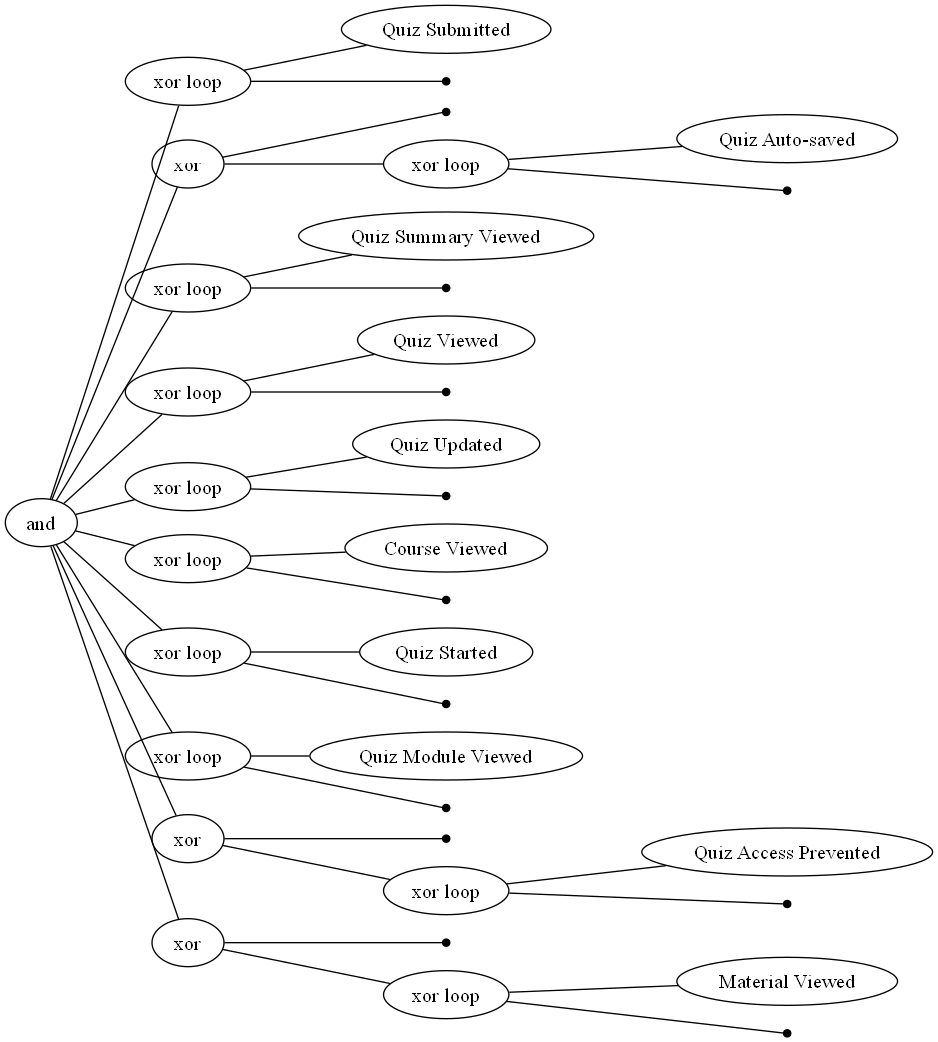

### Petri Net

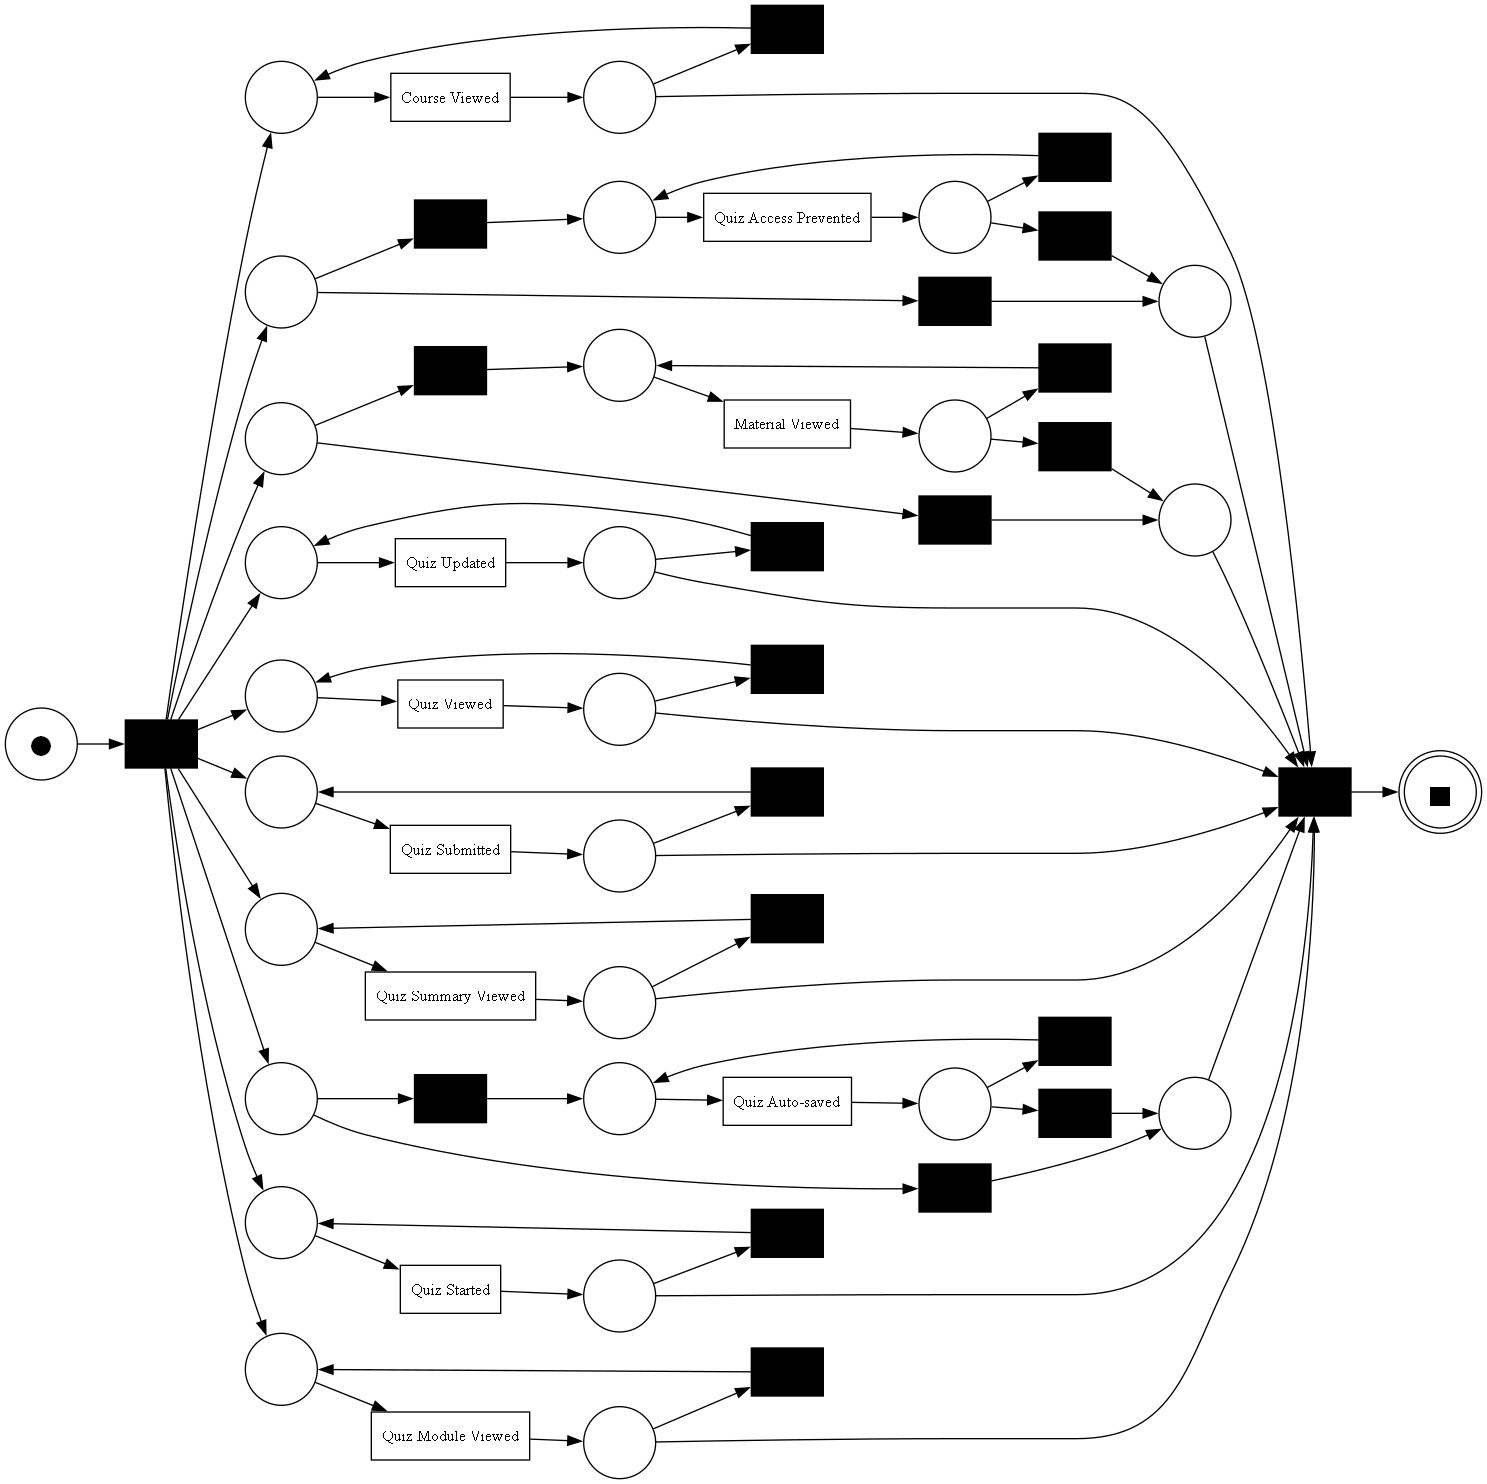

## Visualisasi Process Discovery - Rendah

### Process Tree

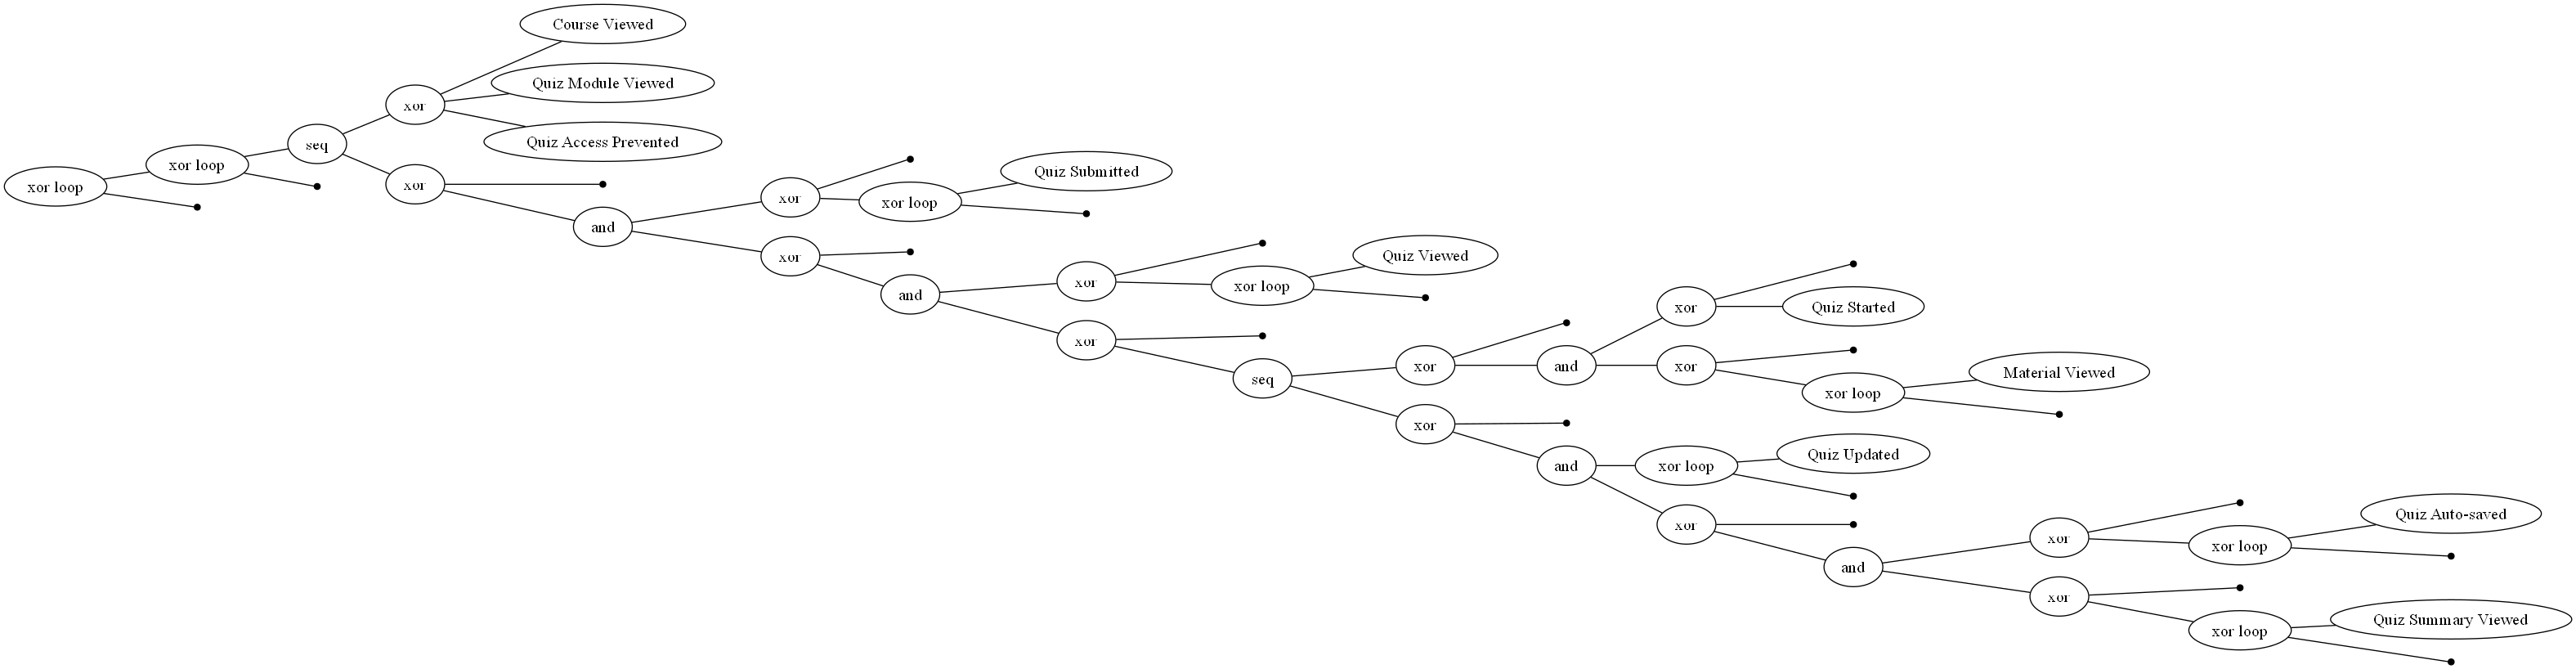

### Petri Net

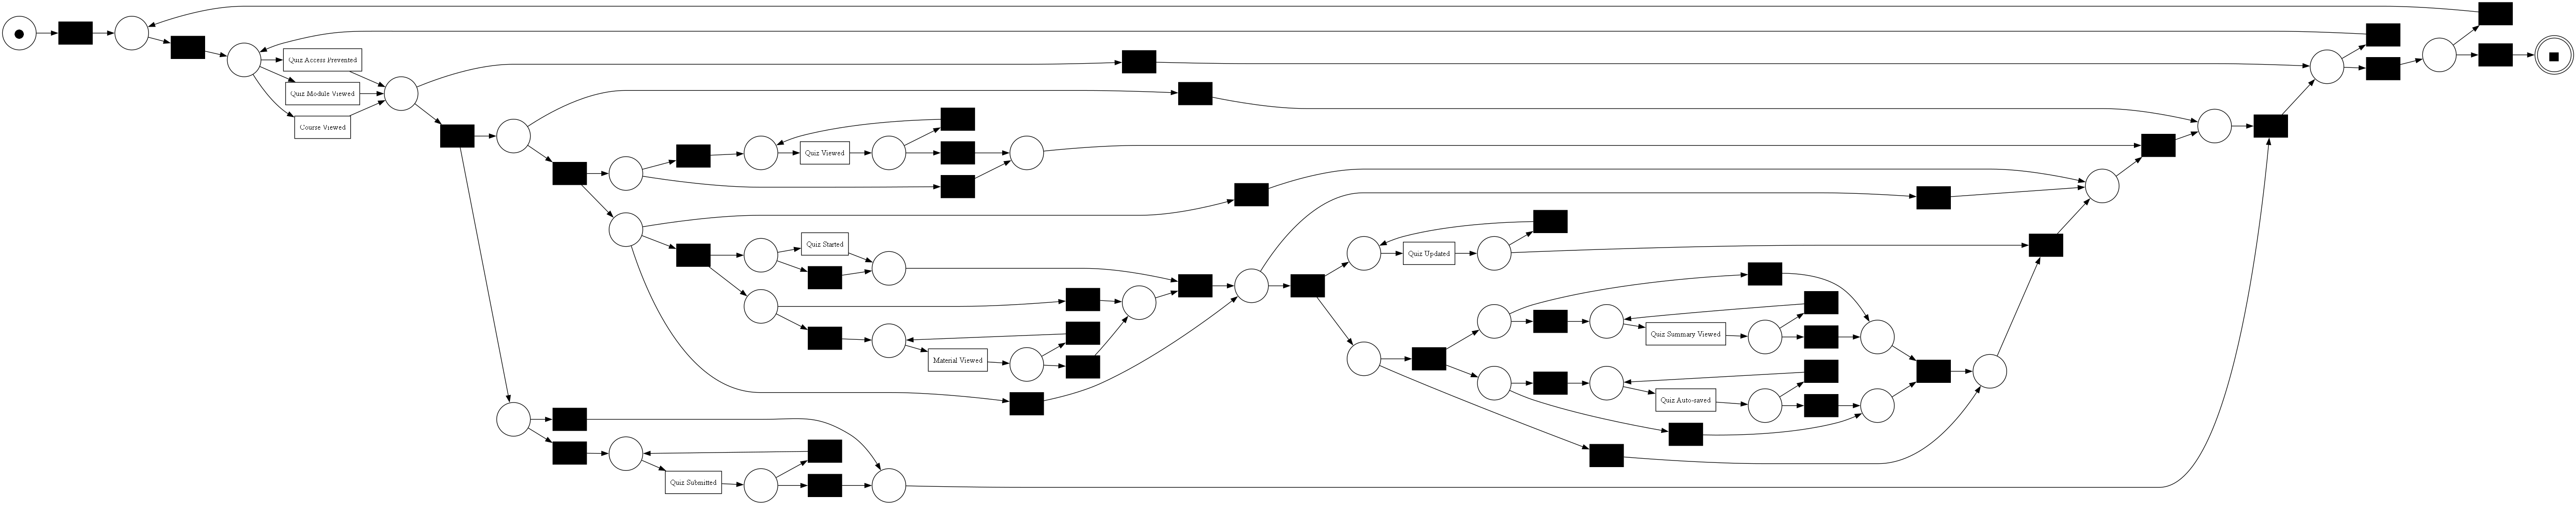

## Visualisasi Process Discovery - Sedang

### Process Tree

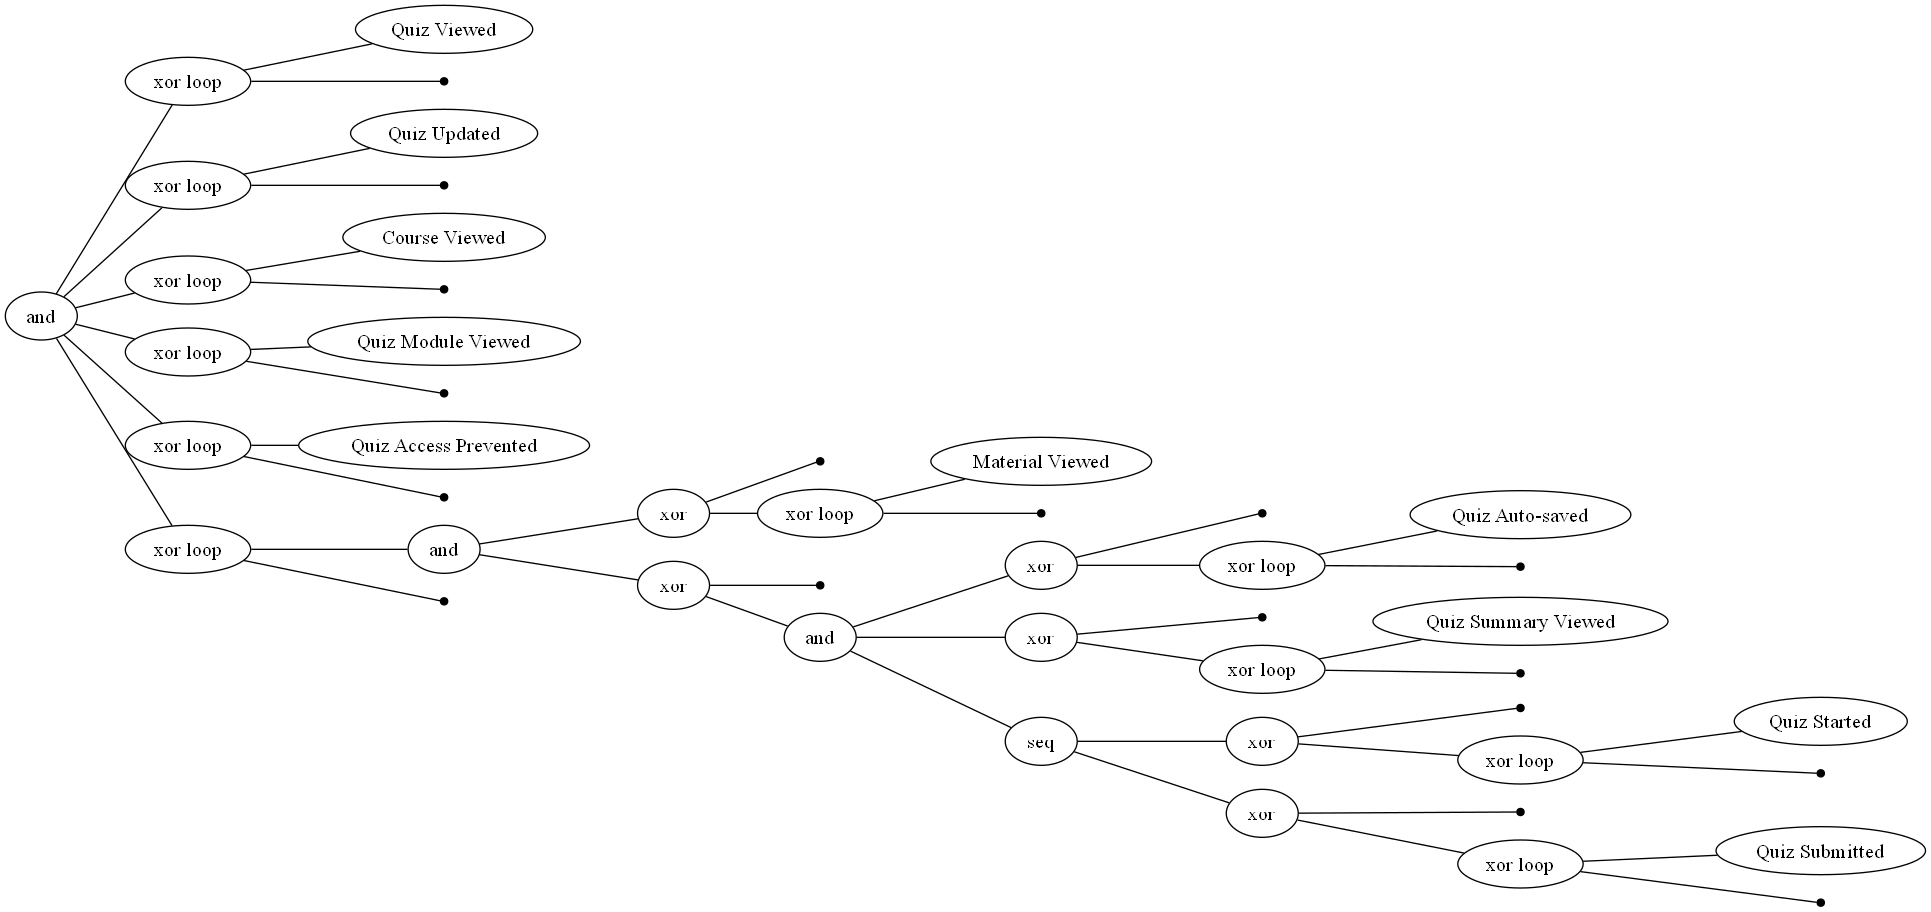

### Petri Net

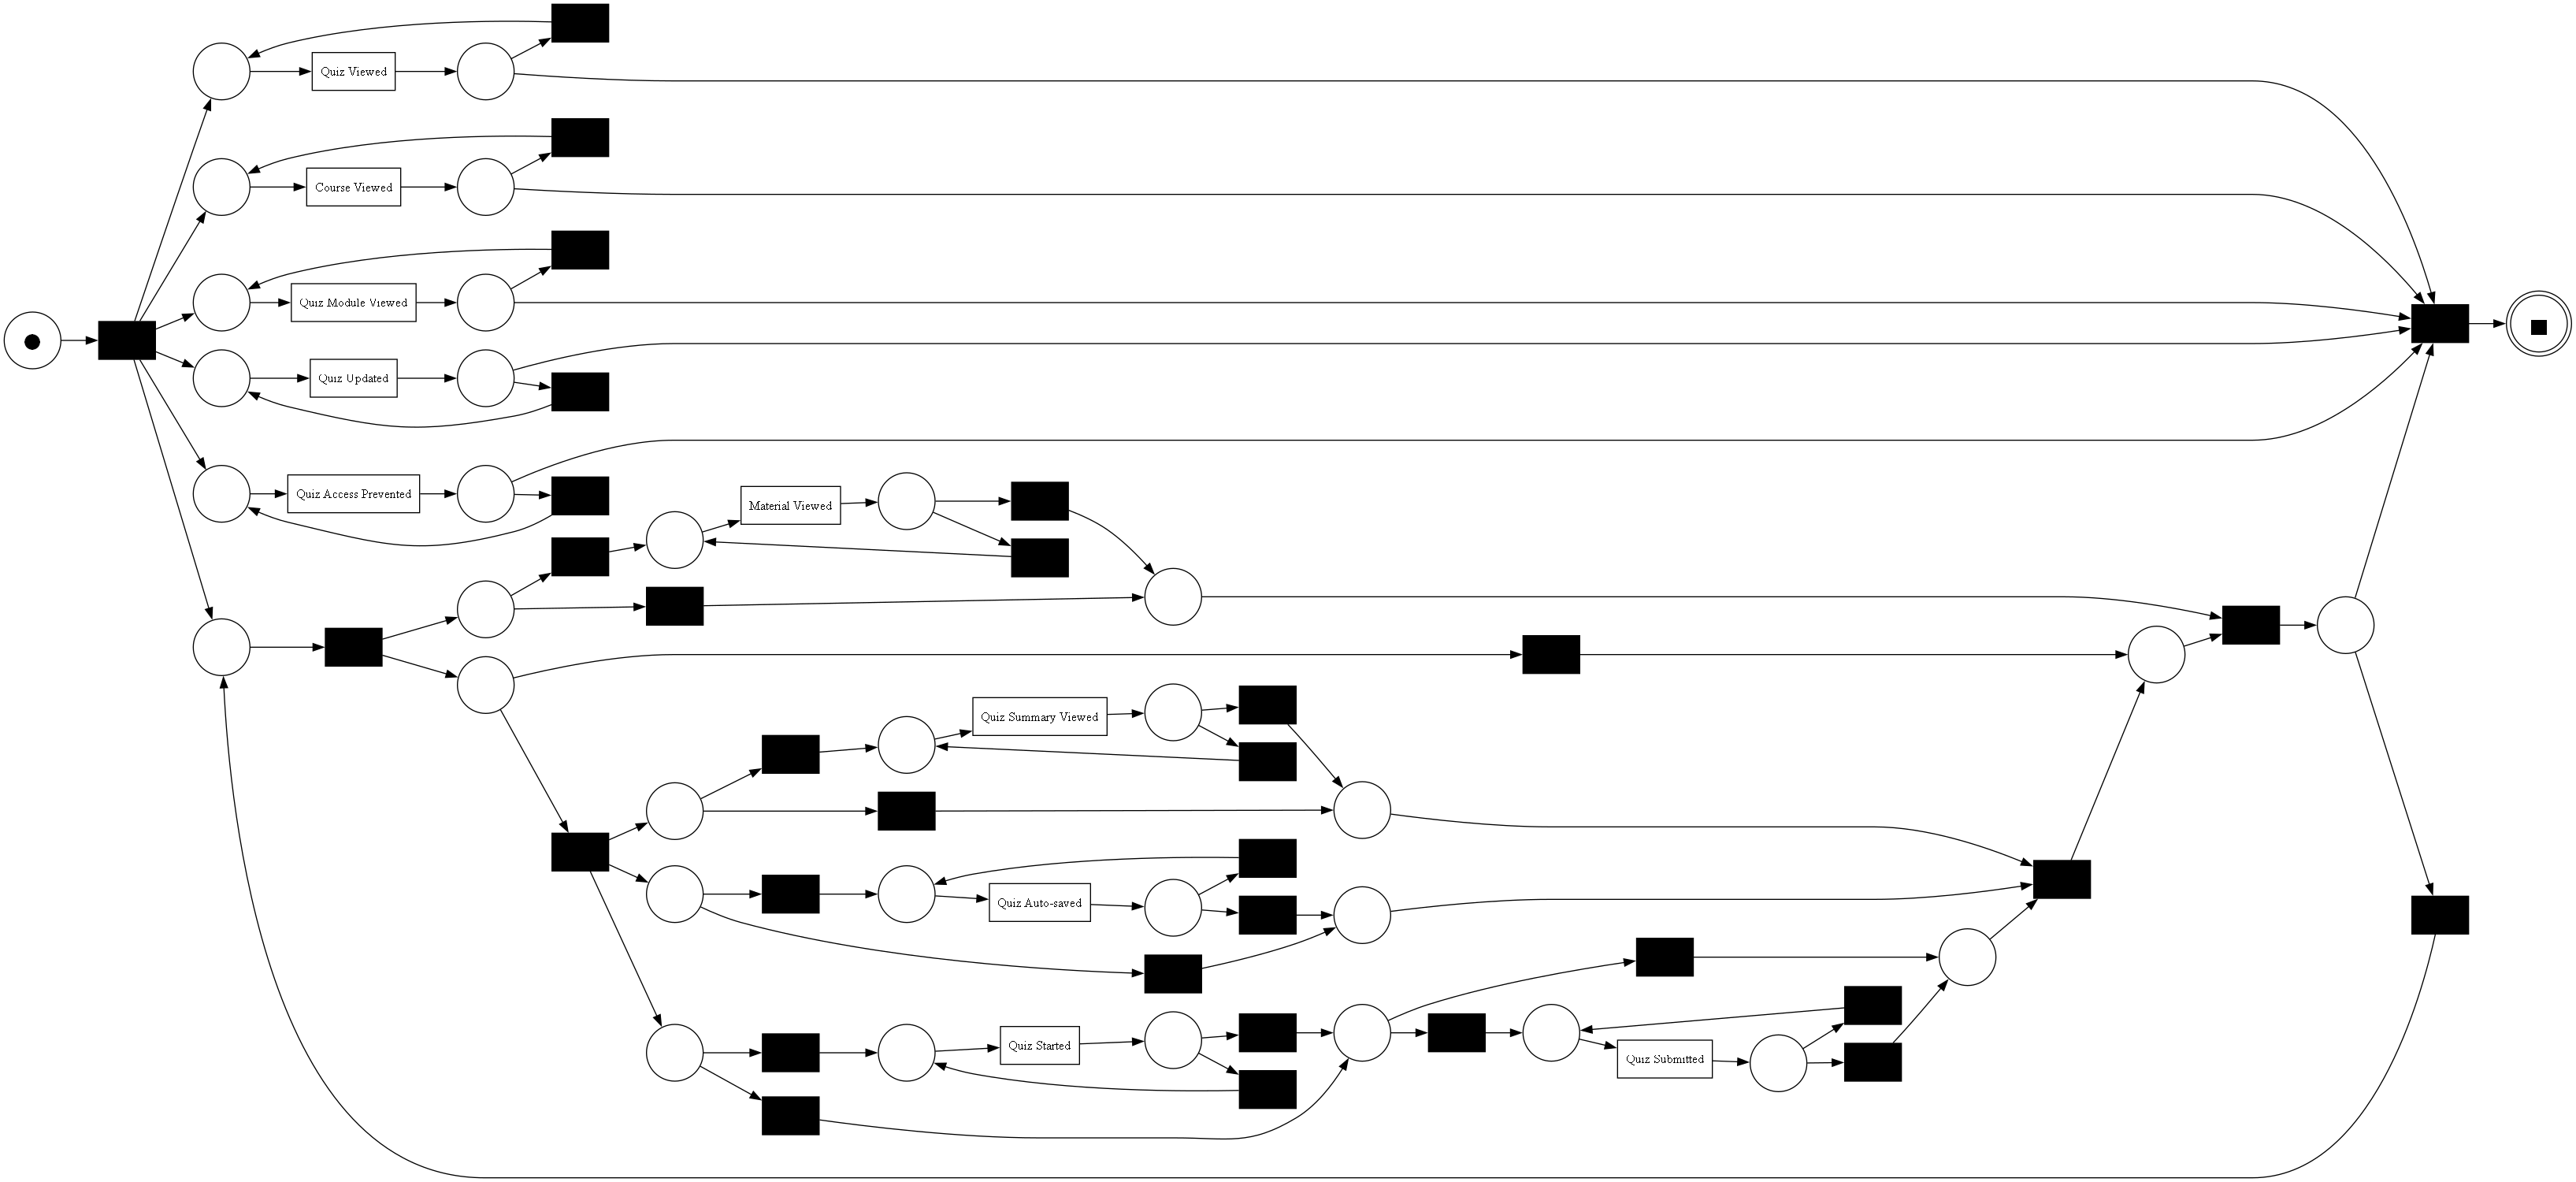

## Visualisasi Process Discovery - Tinggi

### Process Tree

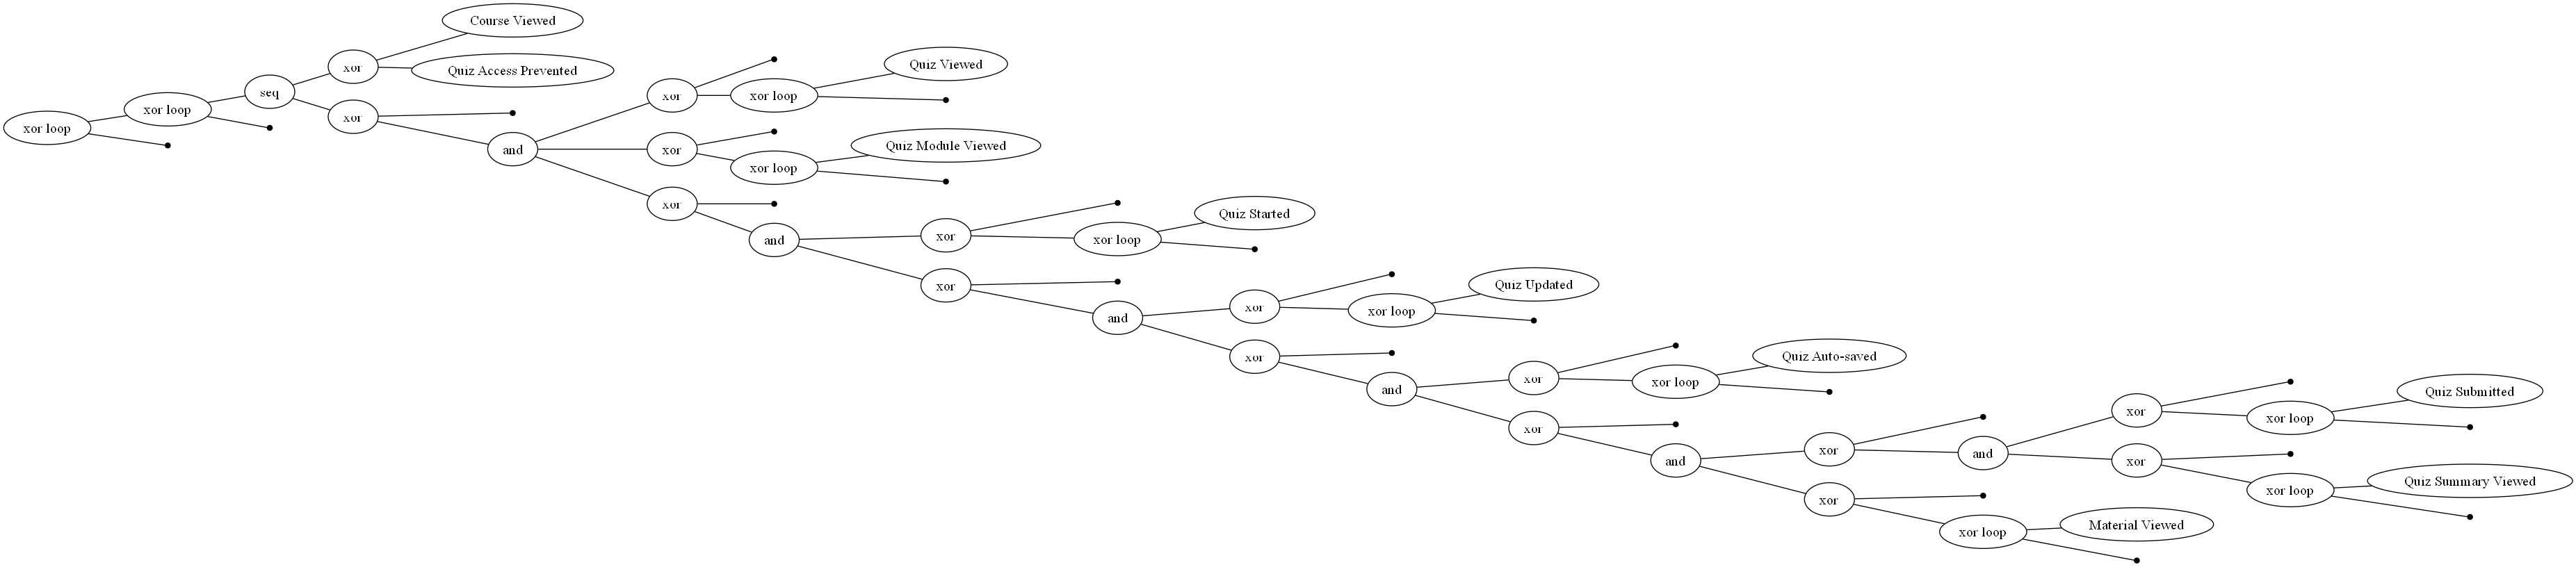

### Petri Net

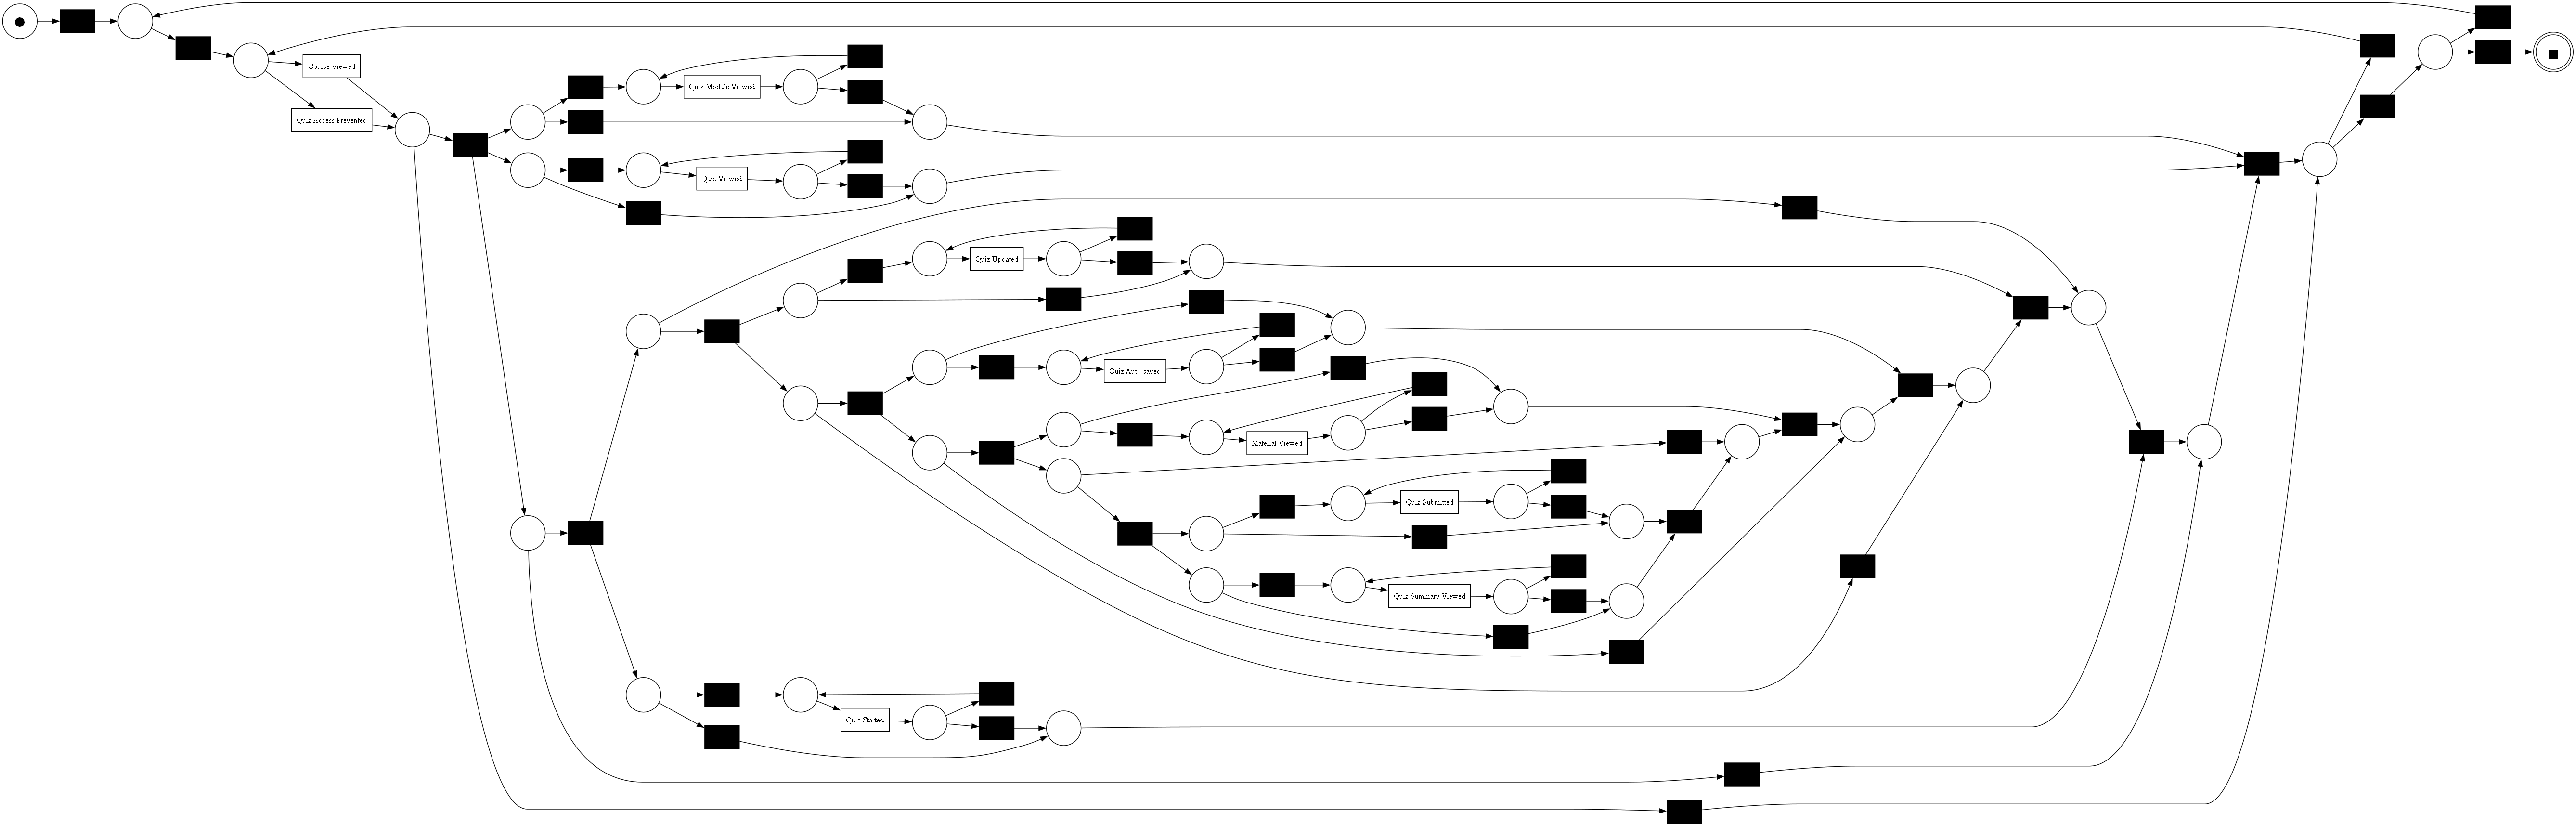

In [25]:
from IPython.display import Image, display, Markdown

visual_labels = ["global", "rendah", "sedang", "tinggi"]

for label in visual_labels:
    display(Markdown(f"## Visualisasi Process Discovery - {label.capitalize()}"))

    process_tree_path = OUTPUT_FIGURES_DIR / f"14_process_tree_{label}.png"
    petri_net_path = OUTPUT_FIGURES_DIR / f"14_petri_net_{label}.png"

    if process_tree_path.exists():
        display(Markdown("### Process Tree"))
        display(Image(filename=str(process_tree_path)))
    else:
        print("Process tree belum ditemukan:", process_tree_path)

    if petri_net_path.exists():
        display(Markdown("### Petri Net"))
        display(Image(filename=str(petri_net_path)))
    else:
        print("Petri net belum ditemukan:", petri_net_path)

# CELL 13 — Simpan hasil lengkap

In [26]:
CONFORMANCE_FULL_PATH = OUTPUT_TABLES_DIR / "14_conformance_global_vs_by_performance_full.csv"

conformance_global_vs_performance.to_csv(
    CONFORMANCE_FULL_PATH,
    index=False
)

print("Hasil conformance lengkap disimpan ke:")
print(CONFORMANCE_FULL_PATH)

Hasil conformance lengkap disimpan ke:
e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\tables\14_conformance_global_vs_by_performance_full.csv


# CELL 14 — Tabel rapi untuk laporan

In [27]:
conformance_table_for_report = conformance_global_vs_performance.copy()

for col in ["fitness", "precision", "generalization", "simplicity"]:
    conformance_table_for_report[col] = conformance_table_for_report[col].astype(float).round(4)

conformance_table_for_report["fit_trace_percentage"] = (
    conformance_table_for_report["fit_trace_percentage"]
    .astype(float)
    .round(2)
)

conformance_table_for_report = conformance_table_for_report[[
    "label_performance",
    "jumlah_case",
    "jumlah_event",
    "jumlah_activity",
    "jumlah_places",
    "jumlah_transitions",
    "fitness",
    "fit_trace_percentage",
    "precision",
    "generalization",
    "simplicity"
]]

display(conformance_table_for_report)

REPORT_TABLE_PATH = OUTPUT_TABLES_DIR / "14_conformance_table_for_report.csv"

conformance_table_for_report.to_csv(
    REPORT_TABLE_PATH,
    index=False
)

print("Tabel siap laporan disimpan ke:")
print(REPORT_TABLE_PATH)

,label_performance,jumlah_case,jumlah_event,jumlah_activity,jumlah_places,jumlah_transitions,fitness,fit_trace_percentage,precision,generalization,simplicity
0,Global,89,113803,10,28,31,1.0,100.0,0.1011,0.8658,0.5842
1,Rendah,15,11530,10,38,54,1.0,100.0,0.1567,0.8748,0.6389
2,Sedang,54,72873,10,35,43,1.0,100.0,0.1008,0.8815,0.6190
3,Tinggi,20,29400,10,49,66,1.0,100.0,0.0991,0.9142,0.6497


Tabel siap laporan disimpan ke:
e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\tables\14_conformance_table_for_report.csv


# CELL 14B — visualisasi metrik conformance

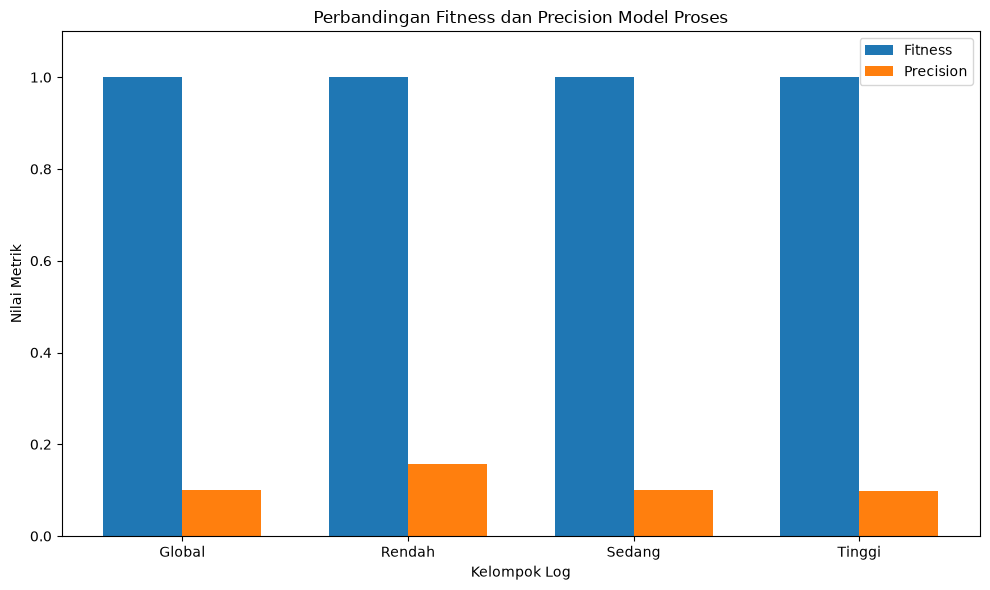

Gambar disimpan ke:
e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures\14_comparison_fitness_precision_by_performance.png


In [28]:
plt.figure(figsize=(10, 6))

plot_df = conformance_table_for_report.copy()

x = np.arange(len(plot_df["label_performance"]))
width = 0.35

plt.bar(
    x - width/2,
    plot_df["fitness"],
    width,
    label="Fitness"
)

plt.bar(
    x + width/2,
    plot_df["precision"],
    width,
    label="Precision"
)

plt.xticks(x, plot_df["label_performance"])
plt.ylim(0, 1.1)
plt.xlabel("Kelompok Log")
plt.ylabel("Nilai Metrik")
plt.title("Perbandingan Fitness dan Precision Model Proses")
plt.legend()
plt.tight_layout()

output_path = OUTPUT_FIGURES_DIR / "14_comparison_fitness_precision_by_performance.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gambar disimpan ke:")
print(output_path)

# CELL 15 — Cek apakah precision naik

In [30]:
global_precision = conformance_table_for_report.loc[
    conformance_table_for_report["label_performance"] == "Global",
    "precision"
].iloc[0]

threshold = 0.005

precision_analysis_rows = []

for _, row in conformance_table_for_report.iterrows():
    label = row["label_performance"]
    precision = row["precision"]
    fitness = row["fitness"]
    delta = precision - global_precision
    
    if label == "Global":
        status = "Model pembanding"
        interpretasi = "Model proses global yang dibentuk dari seluruh main learning log."
    else:
        if delta > threshold:
            status = "Precision meningkat"
            interpretasi = (
                f"Model kelompok {label} memiliki precision lebih tinggi dibandingkan model global. "
                "Hal ini menunjukkan bahwa pemisahan log berdasarkan performa membuat model proses kelompok ini lebih spesifik."
            )
        elif abs(delta) <= threshold:
            status = "Precision relatif sama"
            interpretasi = (
                f"Model kelompok {label} memiliki precision yang relatif sama dengan model global. "
                "Hal ini menunjukkan bahwa pemisahan log belum memberikan perubahan precision yang besar pada kelompok ini."
            )
        else:
            status = "Precision sedikit menurun"
            interpretasi = (
                f"Model kelompok {label} memiliki precision sedikit lebih rendah dibandingkan model global. "
                "Hal ini dapat terjadi karena pola aktivitas dalam kelompok masih bervariasi atau jumlah data kelompok terbatas."
            )
    
    precision_analysis_rows.append({
        "label_performance": label,
        "fitness": fitness,
        "precision": precision,
        "selisih_precision_dari_global": round(delta, 4),
        "status": status,
        "interpretasi": interpretasi
    })

precision_analysis = pd.DataFrame(precision_analysis_rows)

display(precision_analysis)

PRECISION_ANALYSIS_PATH = OUTPUT_TABLES_DIR / "14_precision_analysis_by_performance_revised.csv"

precision_analysis.to_csv(
    PRECISION_ANALYSIS_PATH,
    index=False
)

print("Analisis precision revisi disimpan ke:")
print(PRECISION_ANALYSIS_PATH)

,label_performance,fitness,precision,selisih_precision_dari_global,status,interpretasi
0,Global,1.0,0.1011,0.0000,Model pembanding,Model proses global yang dibentuk dari seluruh...
1,Rendah,1.0,0.1567,0.0556,Precision meningkat,Model kelompok Rendah memiliki precision lebih...
2,Sedang,1.0,0.1008,-0.0003,Precision relatif sama,Model kelompok Sedang memiliki precision yang ...
3,Tinggi,1.0,0.0991,-0.0020,Precision relatif sama,Model kelompok Tinggi memiliki precision yang ...


Analisis precision revisi disimpan ke:
e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\tables\14_precision_analysis_by_performance_revised.csv


# CELL 16 grafik fitness vs precision

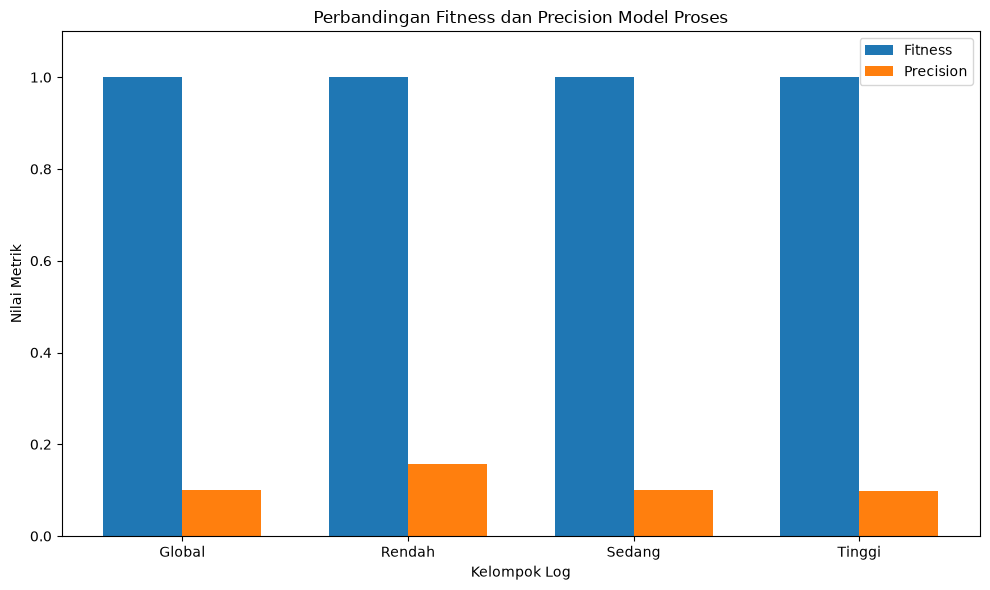

Gambar disimpan ke:
e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures\14_comparison_fitness_precision_by_performance.png


In [31]:
plt.figure(figsize=(10, 6))

plot_df = conformance_table_for_report.copy()

x = np.arange(len(plot_df["label_performance"]))
width = 0.35

plt.bar(
    x - width/2,
    plot_df["fitness"],
    width,
    label="Fitness"
)

plt.bar(
    x + width/2,
    plot_df["precision"],
    width,
    label="Precision"
)

plt.xticks(x, plot_df["label_performance"])
plt.ylim(0, 1.1)
plt.xlabel("Kelompok Log")
plt.ylabel("Nilai Metrik")
plt.title("Perbandingan Fitness dan Precision Model Proses")
plt.legend()
plt.tight_layout()

output_path = OUTPUT_FIGURES_DIR / "14_comparison_fitness_precision_by_performance.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gambar disimpan ke:")
print(output_path)